In [2]:
import numpy as np
import os,sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from plotly.offline import iplot
import plotly as py
import warnings
warnings.filterwarnings('ignore')


In [3]:
pd.set_option('display.max_rows',200)
pd.set_option('display.max_columns',25)
pd.set_option('display.width',200)

In [4]:
df=pd.read_csv('parkinsons_uci_style_dataset00.csv')
df

,name,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,D1ABNINSAC46F240120171756.wav,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,D2ABNINSAC46F240120171756.wav,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,VA1ABNINSAC46F240120171758.wav,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,VA2ABNINSAC46F240120171759.wav,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,VE1ABNINSAC46F240120171800.wav,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VI2VLIATFOO55M300320171247.wav,VITO L,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,VO1VLIATFOO55M300320171247.wav,VITO L,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,VO2VLIATFOO55M300320171248.wav,VITO L,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,VU1VLIATFOO55M300320171248.wav,VITO L,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


In [73]:
df=df.drop(columns=['name'])

In [74]:
df.shape

(668, 24)

In [75]:
df.isnull().sum()

subject              0
MDVP:Fo(Hz)          3
MDVP:Fhi(Hz)         3
MDVP:Flo(Hz)         3
MDVP:Jitter(%)      50
MDVP:Jitter(Abs)    50
MDVP:RAP            50
MDVP:PPQ            50
Jitter:DDP          50
MDVP:Shimmer        50
MDVP:Shimmer(dB)    50
Shimmer:APQ3        50
Shimmer:APQ5        50
MDVP:APQ            50
Shimmer:DDA         50
NHR                  3
HNR                  3
RPDE                50
DFA                  3
spread1              3
spread2              3
D2                   6
PPE                  3
status               0
dtype: int64

In [76]:
temp_df = df.groupby('subject').ffill().bfill()
temp_df

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


In [77]:
temp_df['subject']=df['subject']

In [78]:
temp_df=temp_df[['subject','MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE', 'status']]

In [79]:
temp_df.isnull().sum()

subject             0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
status              0
dtype: int64

In [80]:
temp_df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VITO L,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,VITO L,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,VITO L,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,VITO L,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


In [81]:
temp_df['status'].value_counts()

status
0    349
1    319
Name: count, dtype: int64

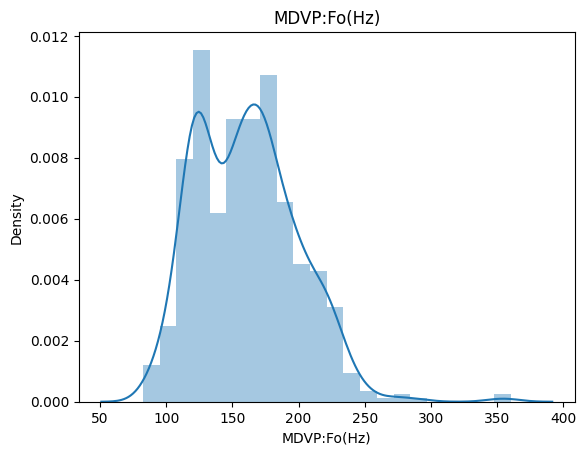

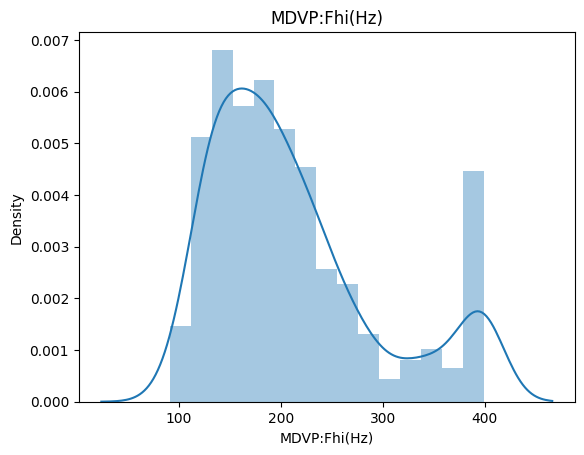

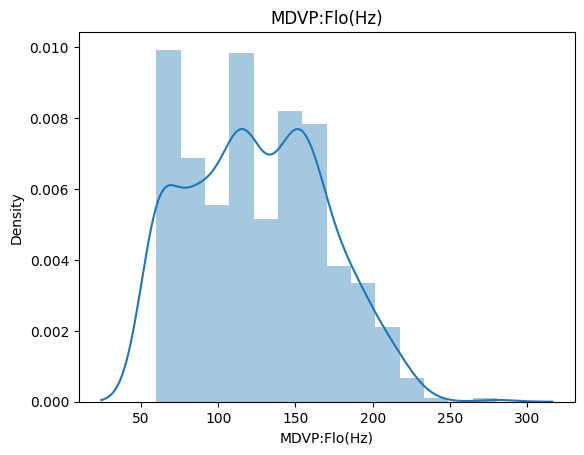

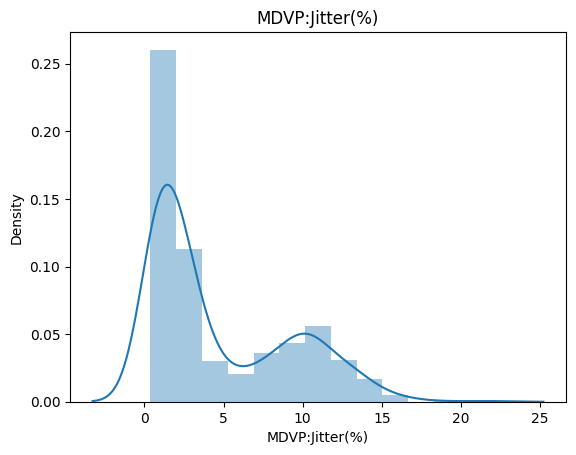

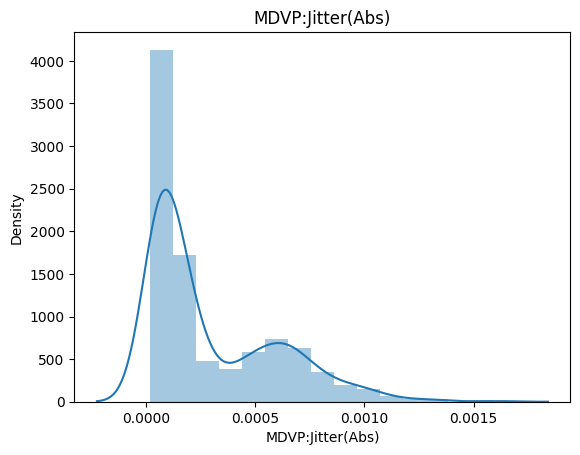

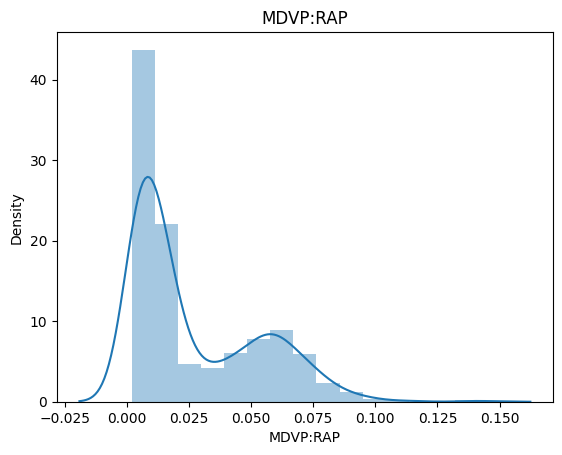

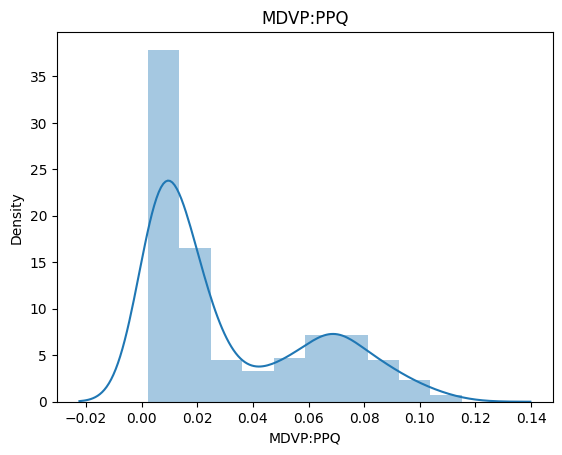

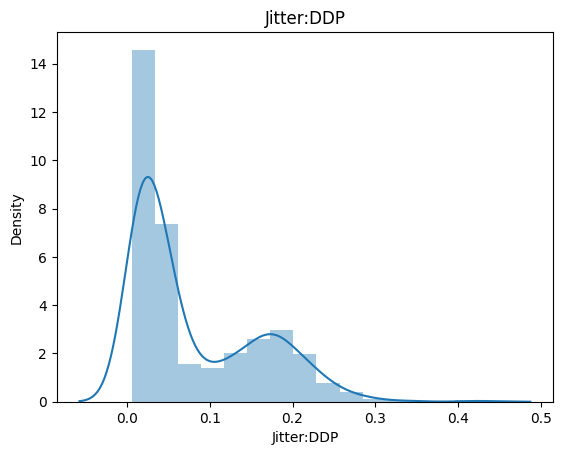

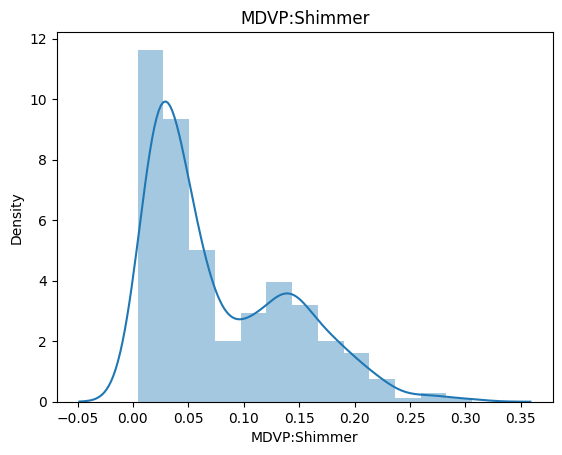

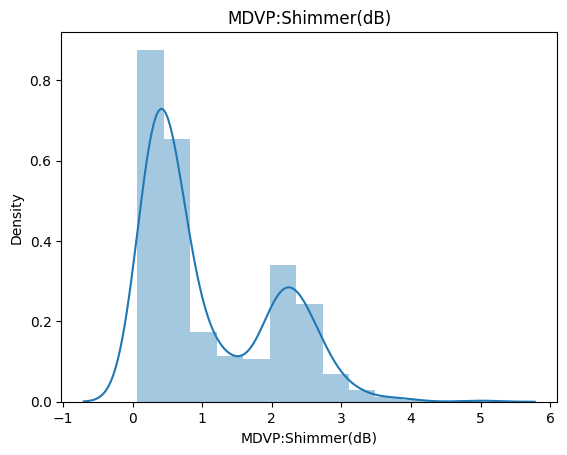

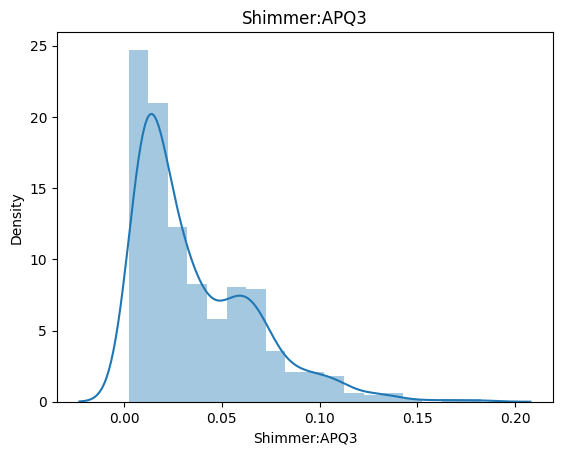

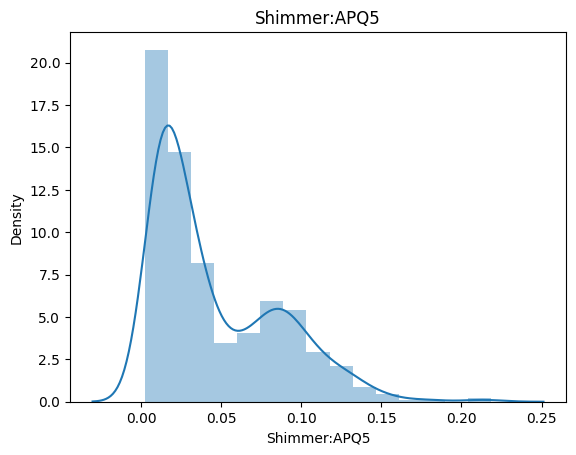

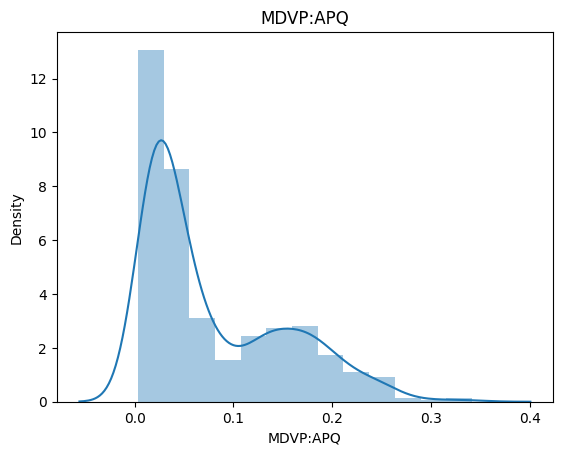

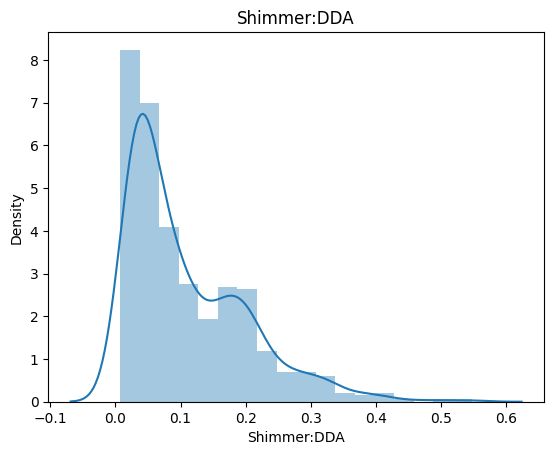

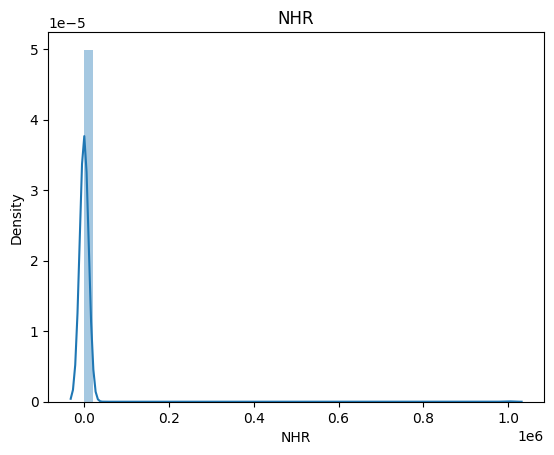

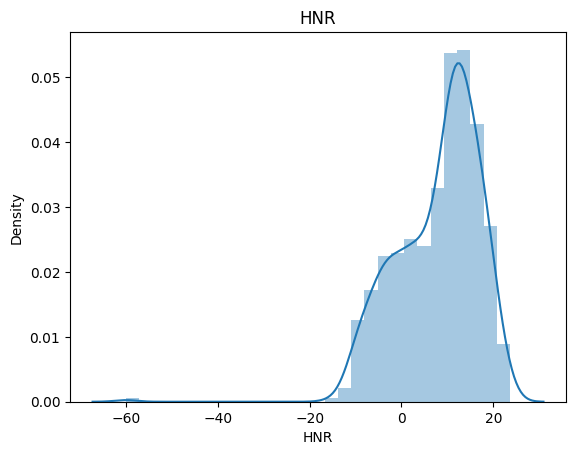

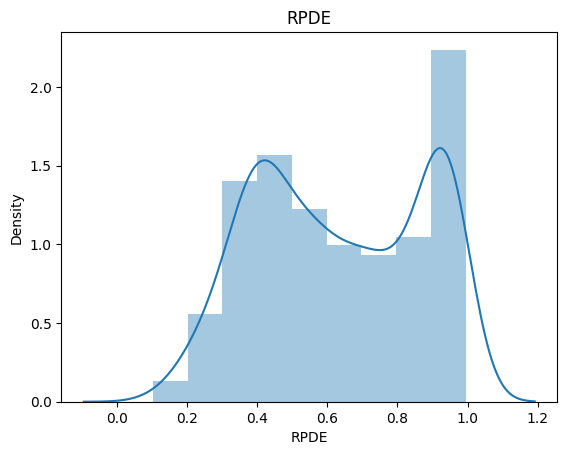

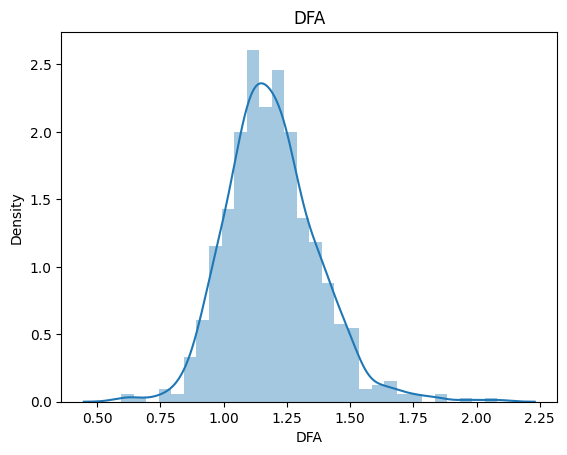

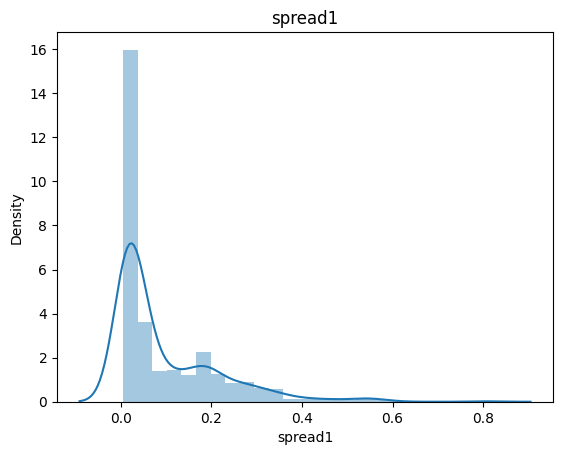

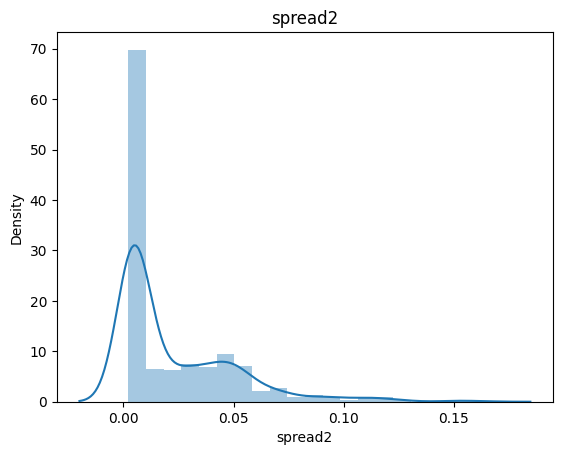

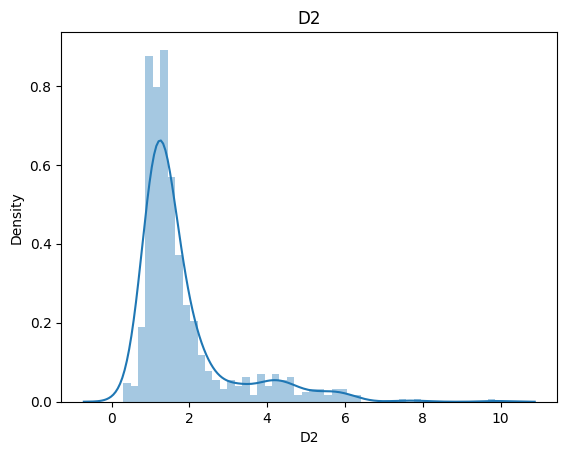

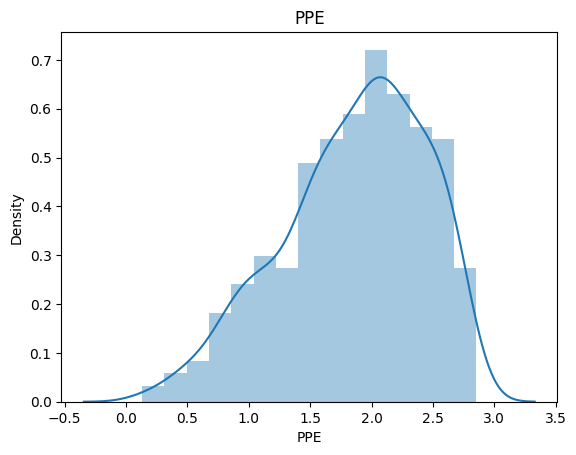

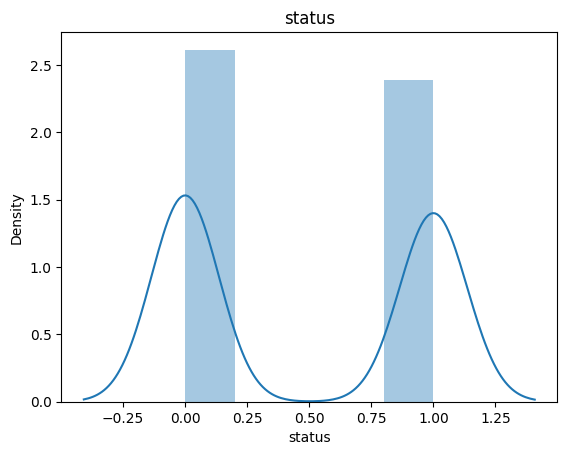

In [13]:
#find the distribution of the column

def distplot(col):
    sns.distplot(df[col])
    plt.title(col)
    plt.savefig(f"plots/{col}.png", dpi=300, bbox_inches='tight')
    plt.show()

for i in list(df.columns[1:]):
    distplot(i)


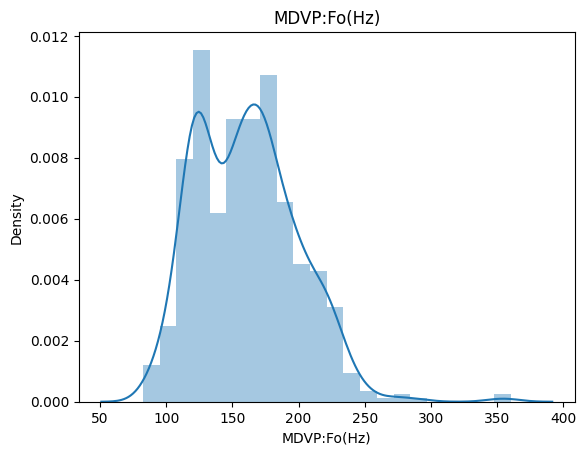

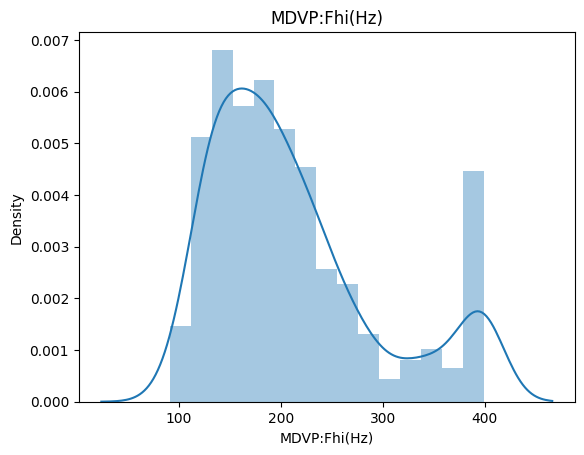

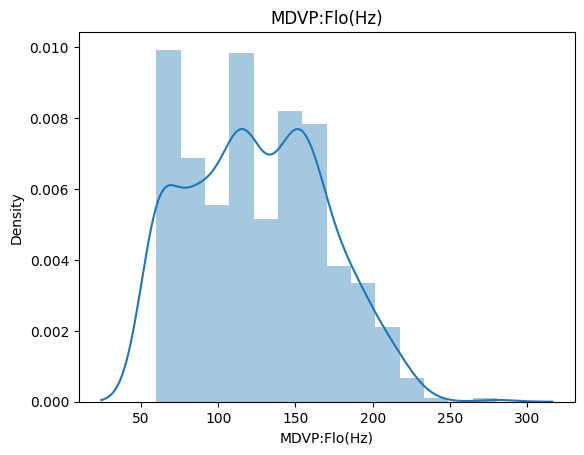

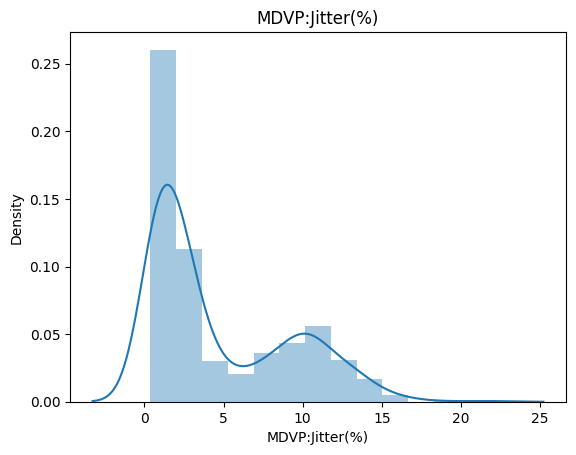

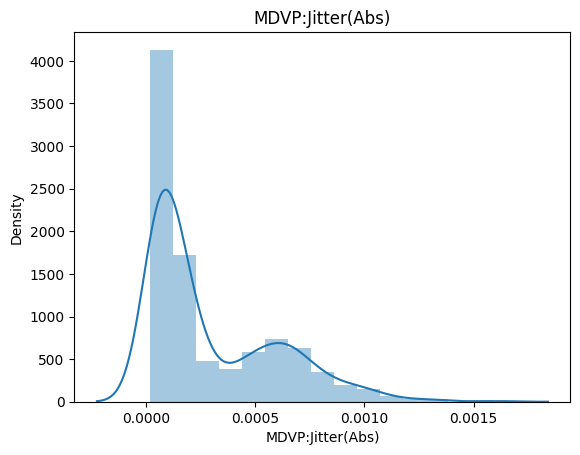

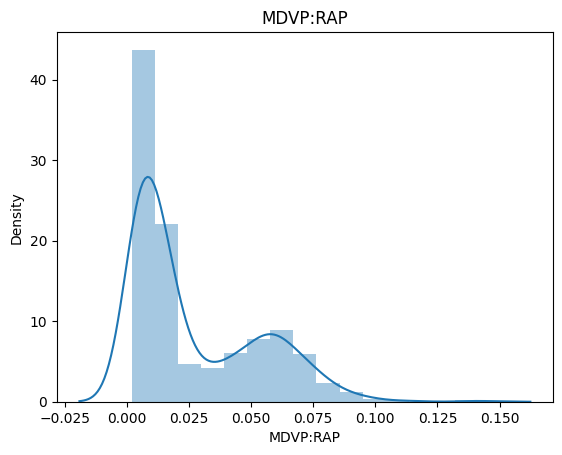

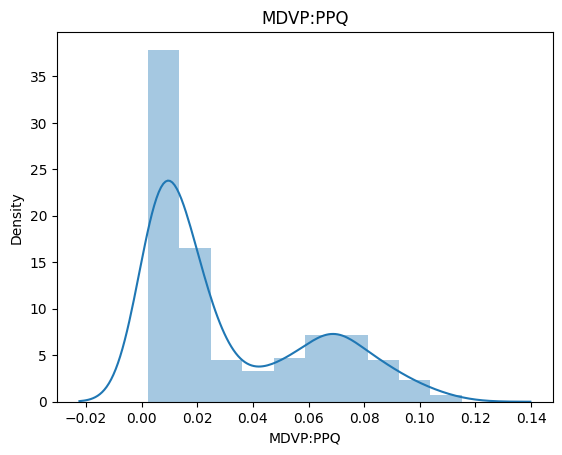

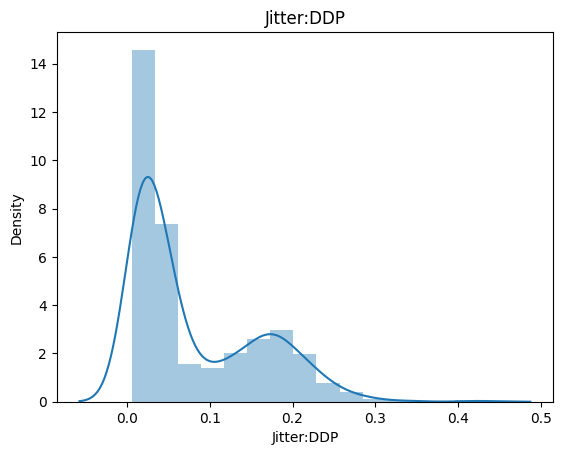

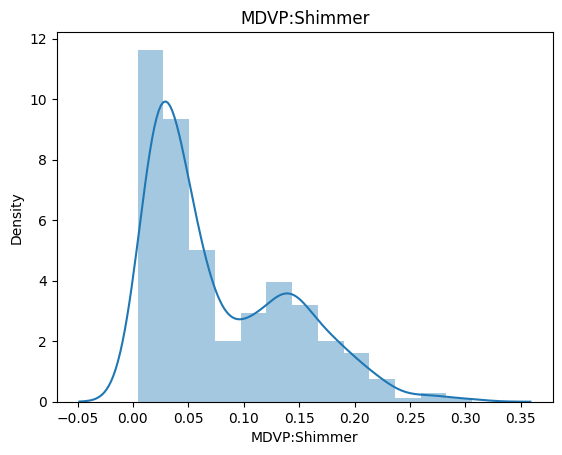

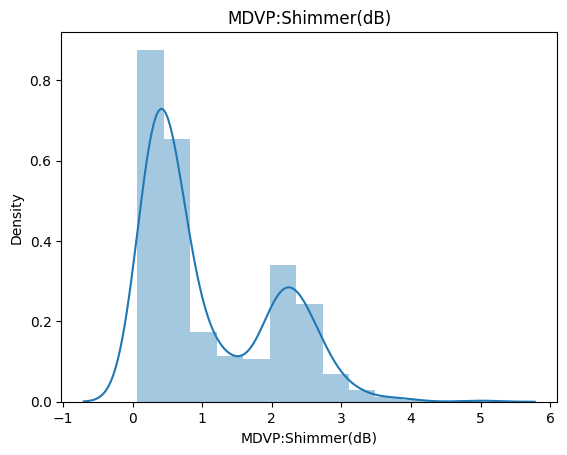

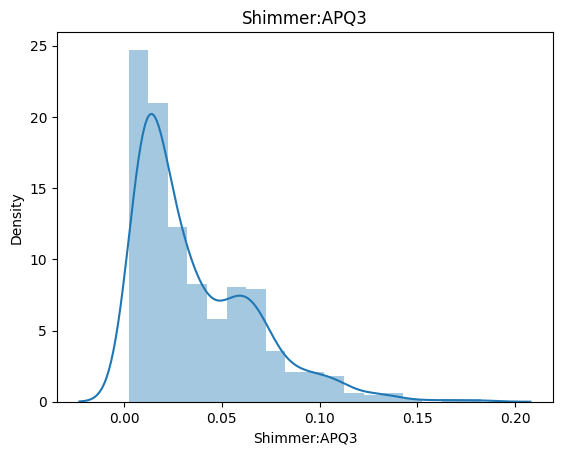

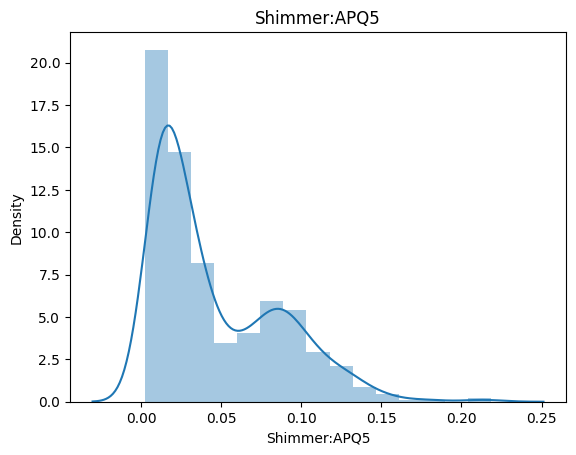

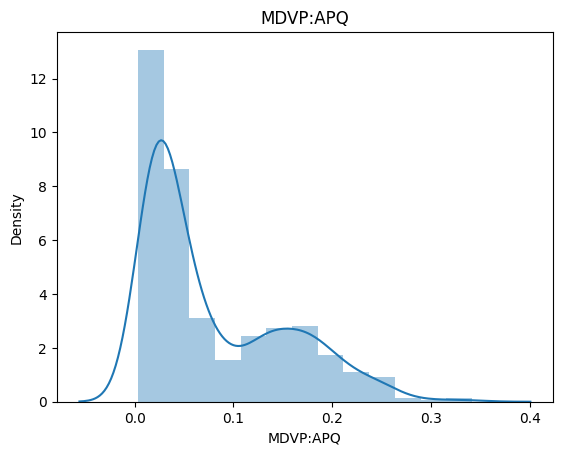

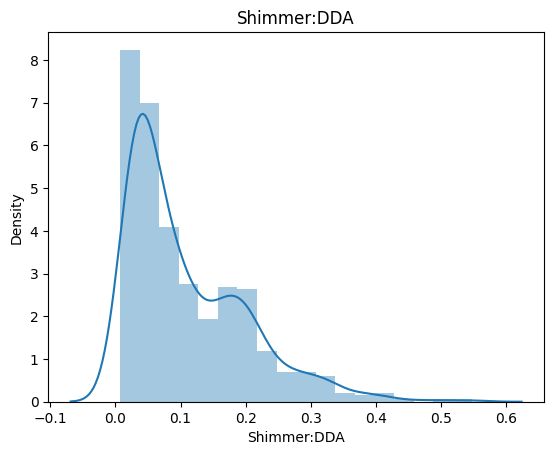

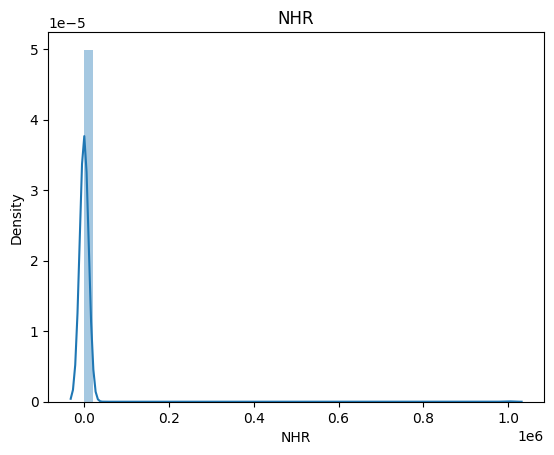

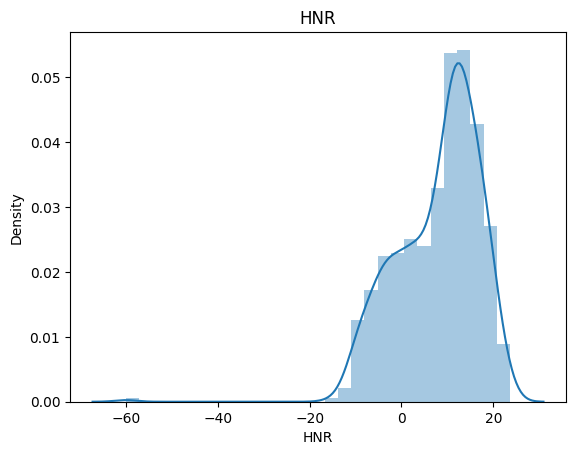

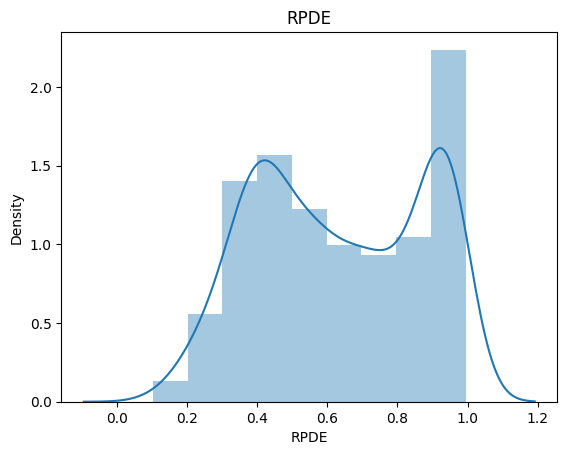

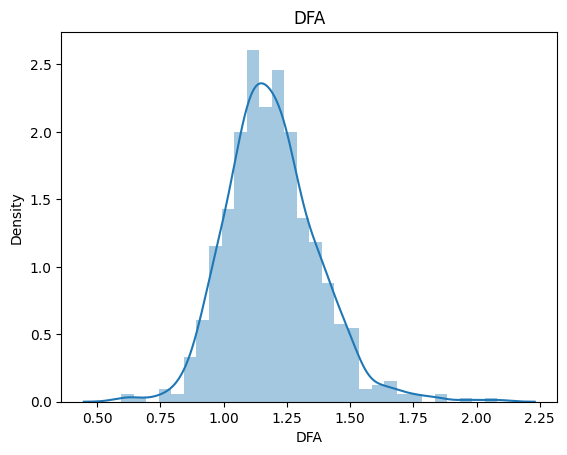

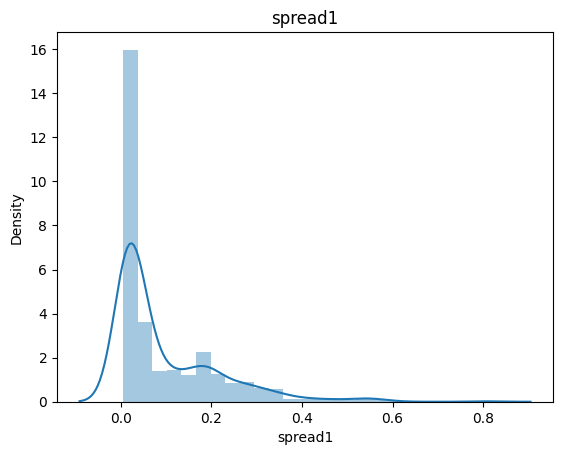

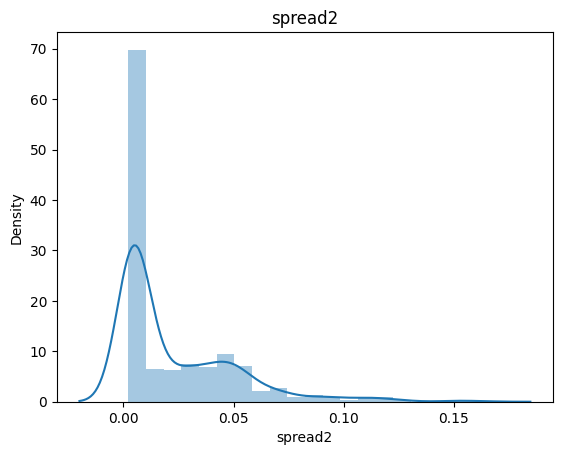

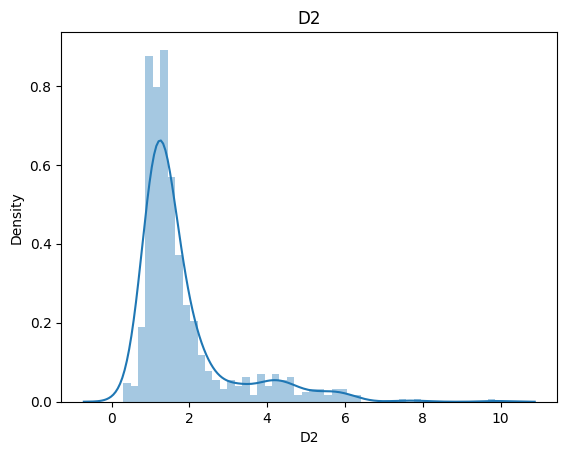

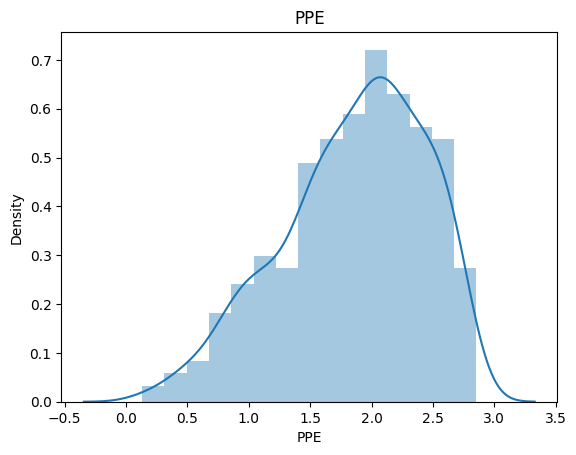

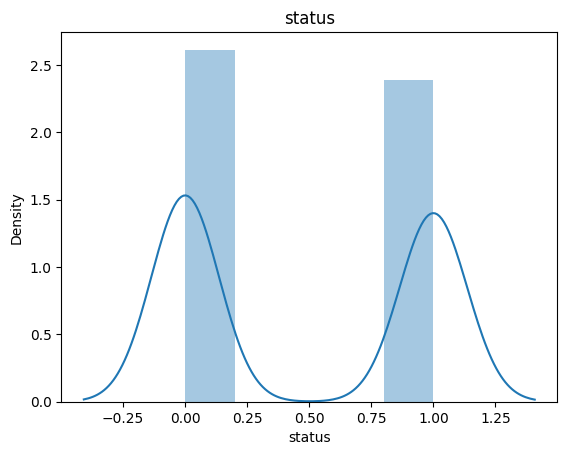

In [14]:
import os

os.makedirs("plots", exist_ok=True)

def distplot(col):
    sns.distplot(df[col])
    plt.title(col)
    plt.savefig(f"plots/{col}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

for i in list(df.columns[1:]):
    distplot(i)

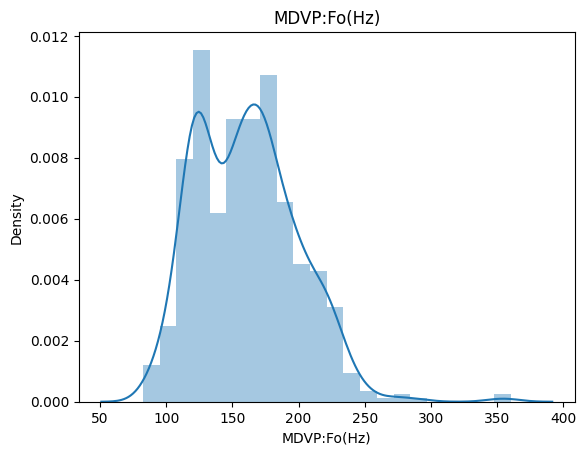

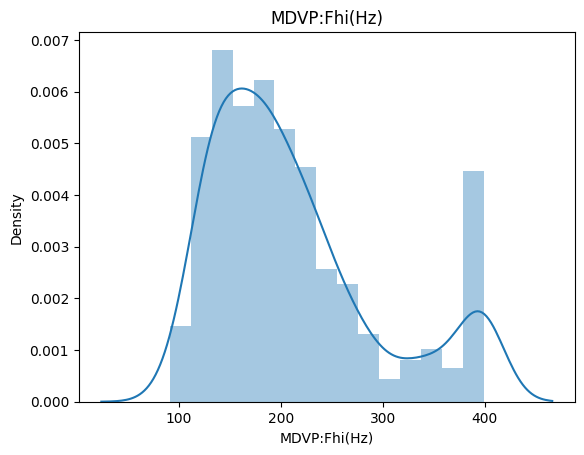

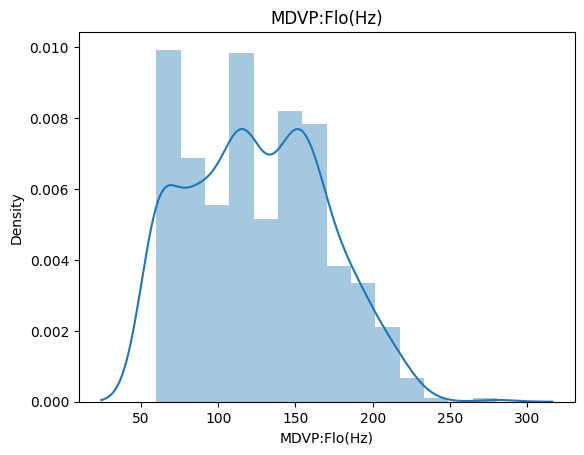

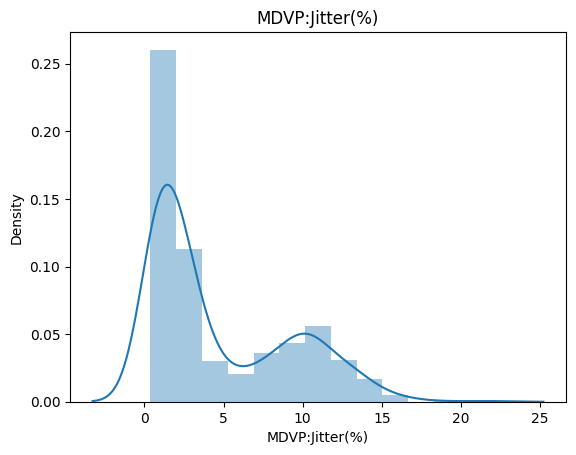

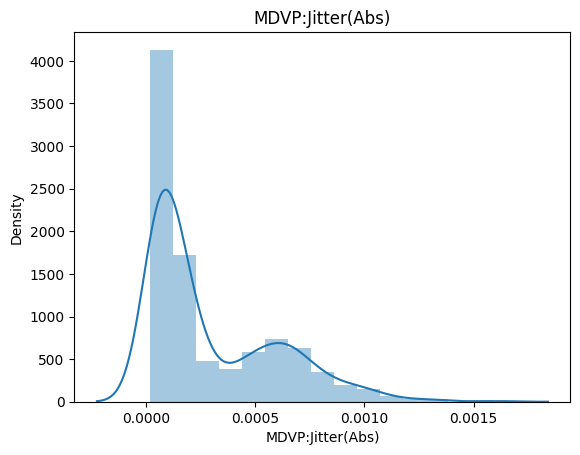

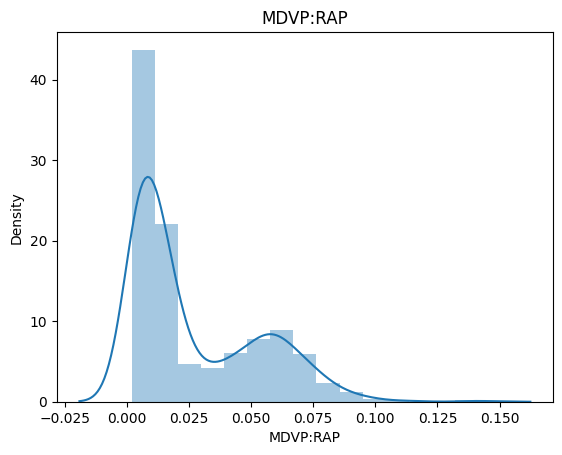

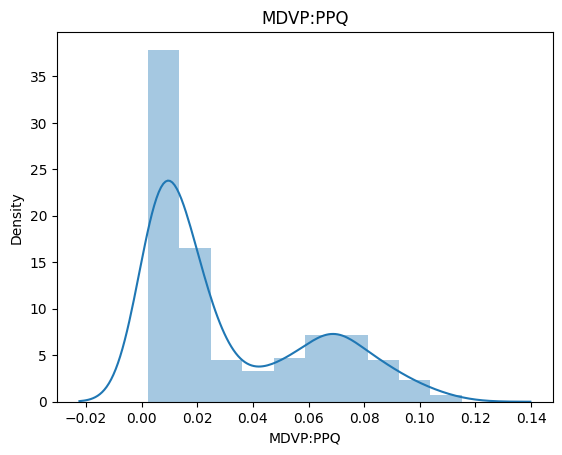

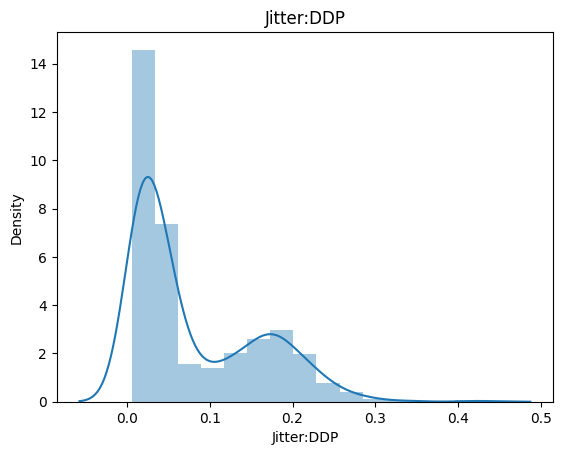

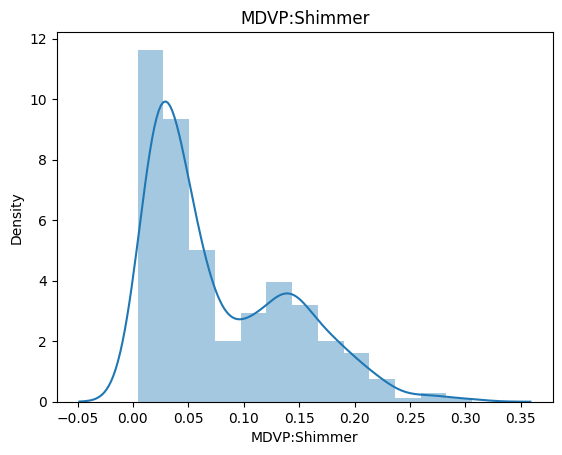

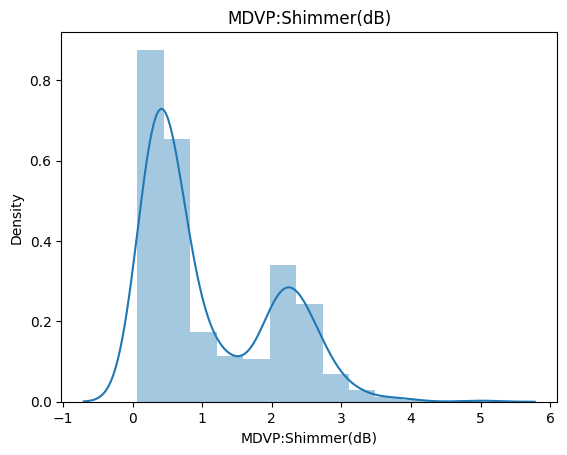

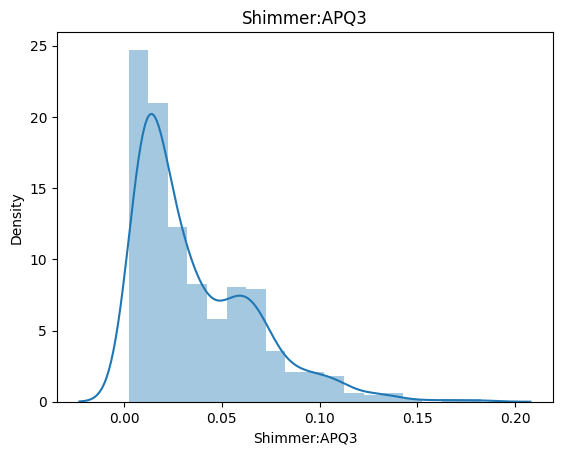

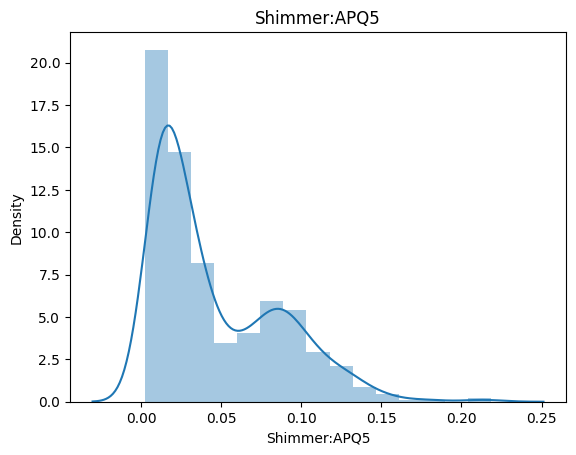

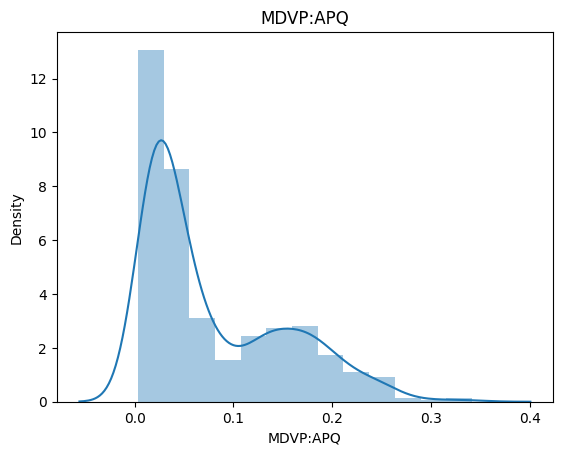

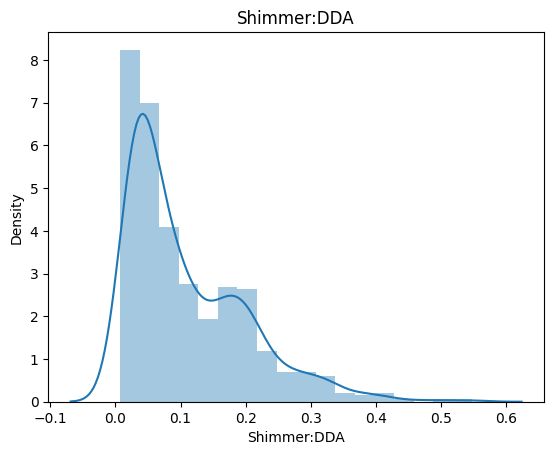

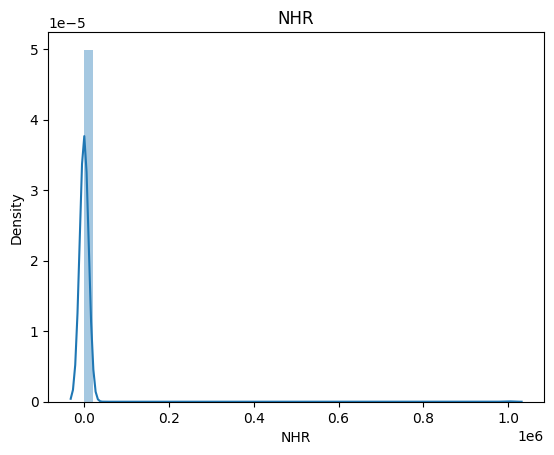

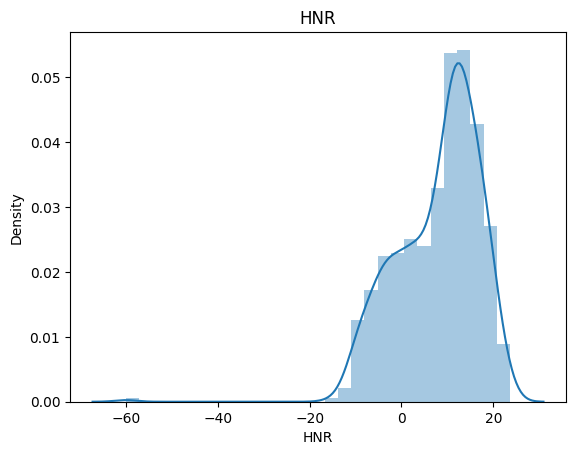

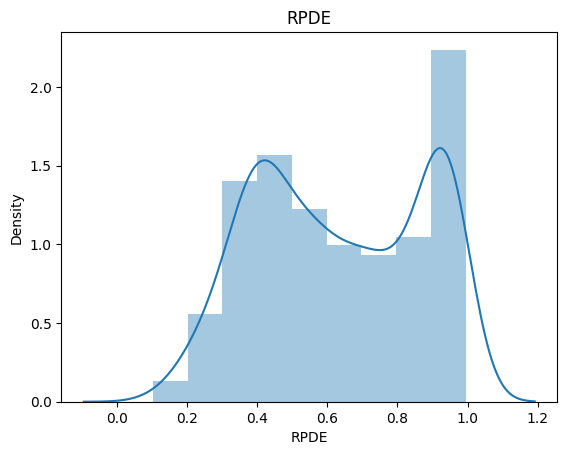

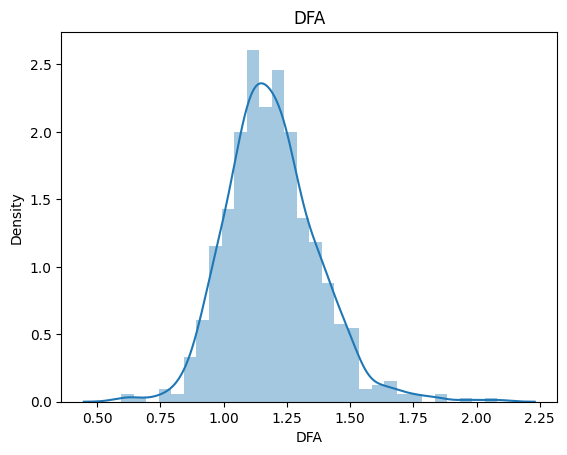

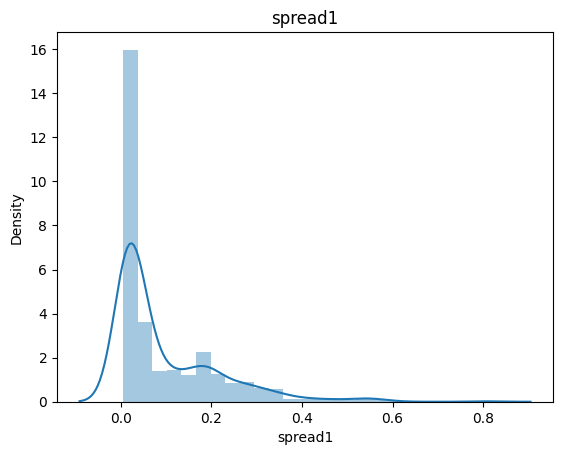

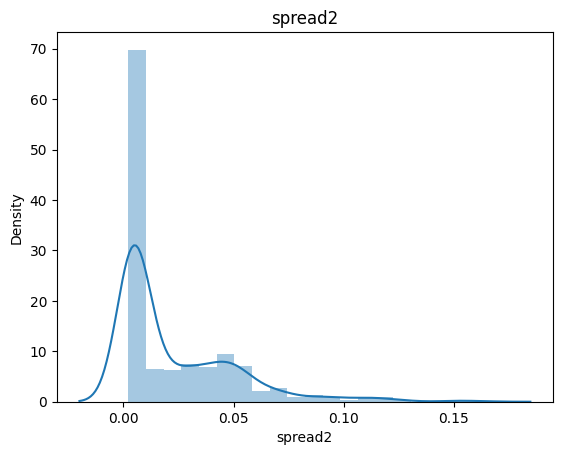

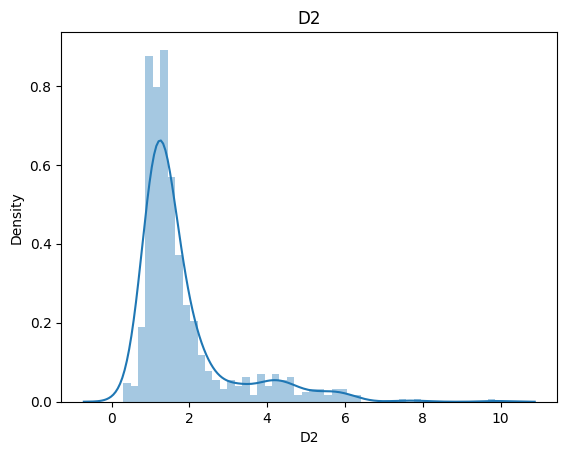

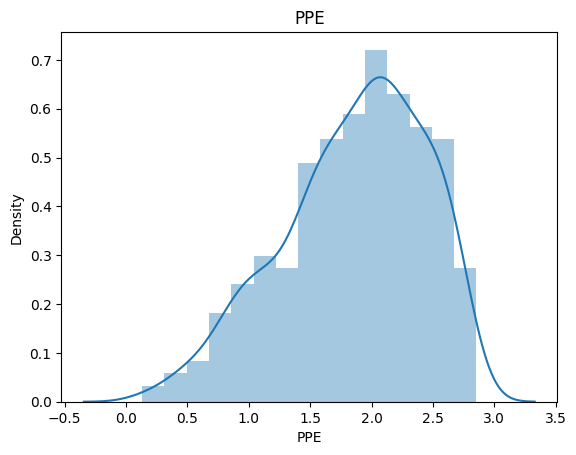

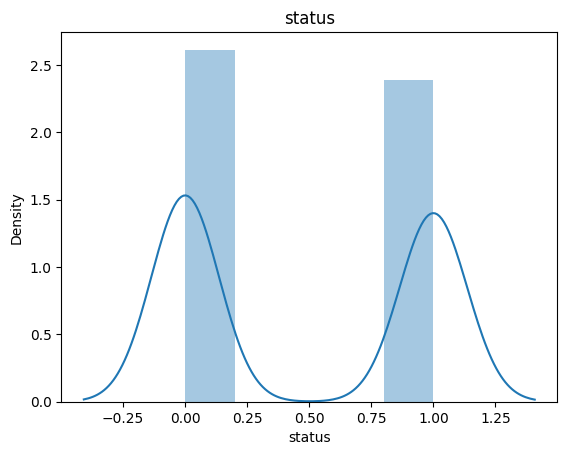

In [15]:
import os

os.makedirs("boxplots", exist_ok=True)

def boxplots(col):
    sns.boxplot(df[col])
    plt.title(col)
    plt.savefig(f"plots/{col}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

for i in list(df.columns[1:]):
    distplot(i)

<Axes: >

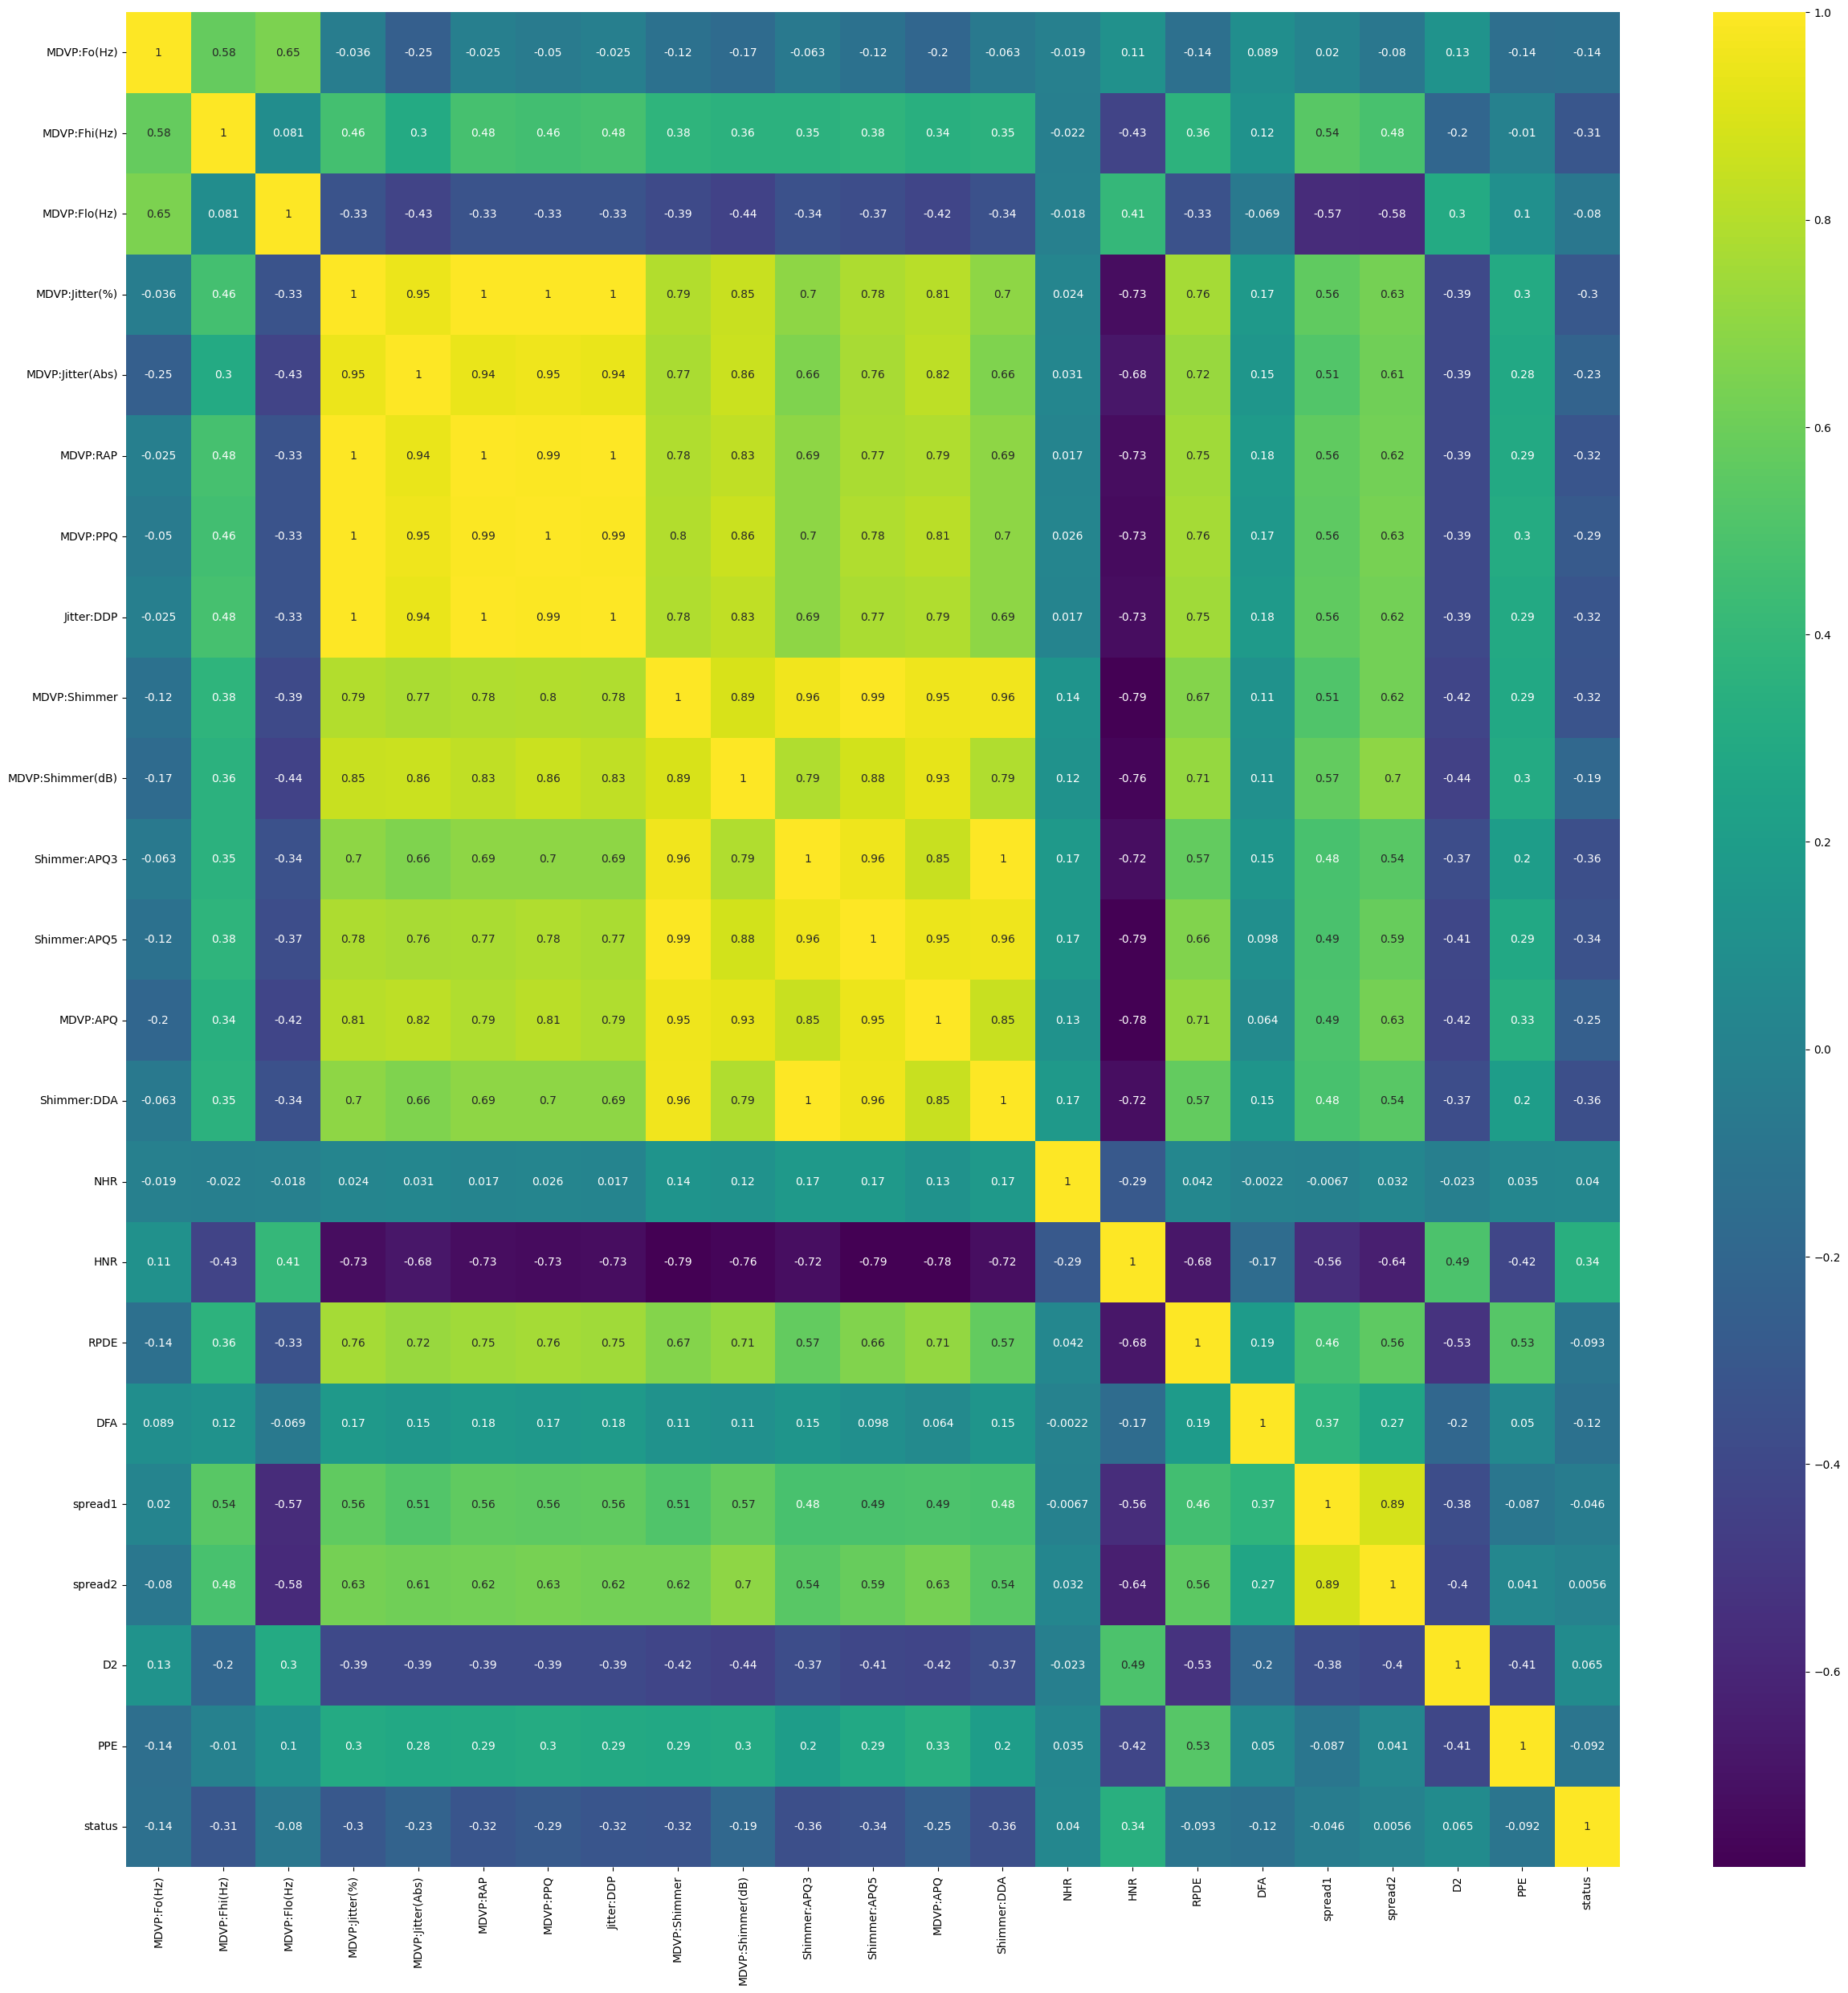

In [77]:
#find correlation
plt.figure(figsize=(30,30))
corr=temp_df.iloc[:,1:].corr()
sns.heatmap(corr,annot=True,cmap='viridis')



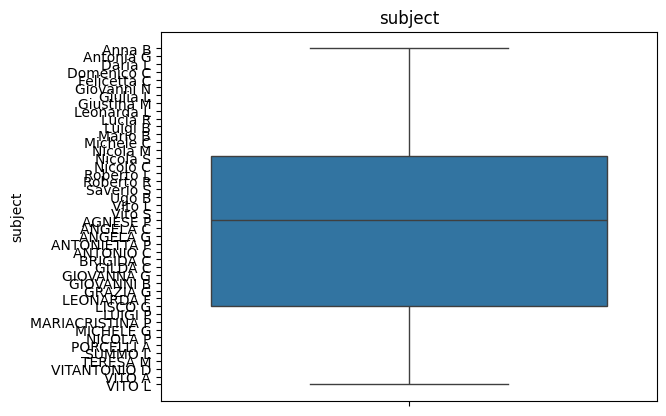

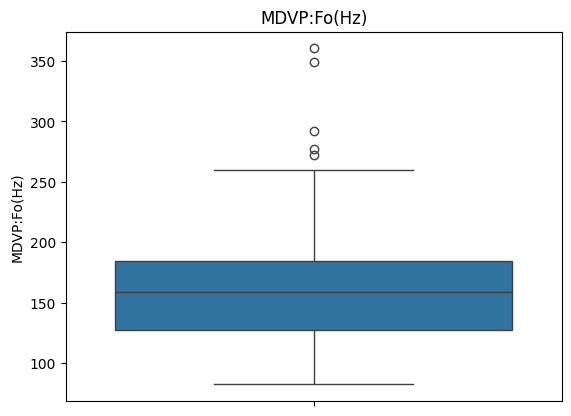

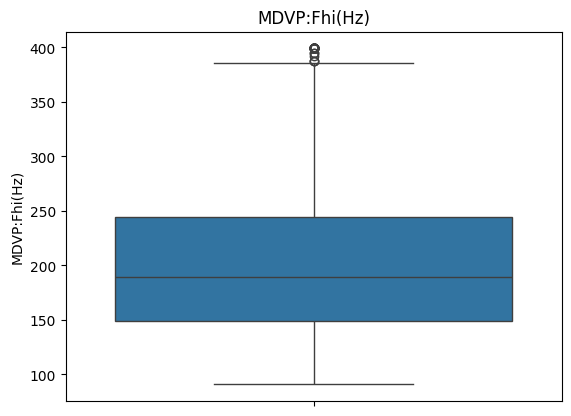

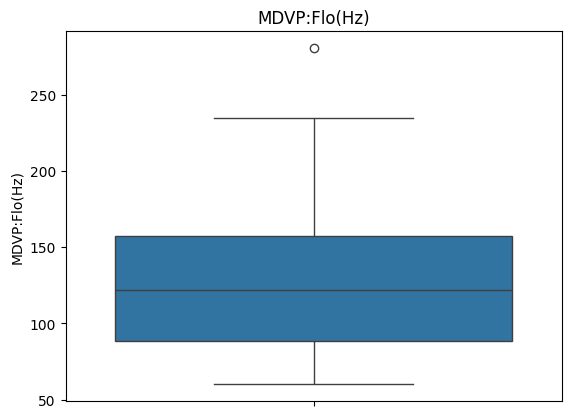

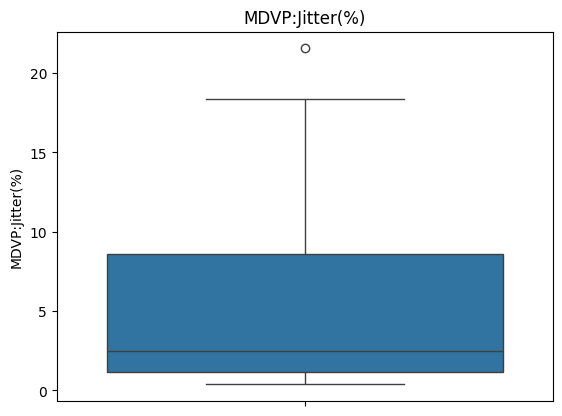

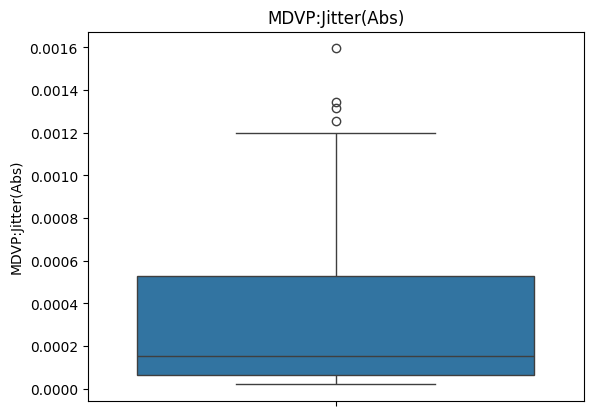

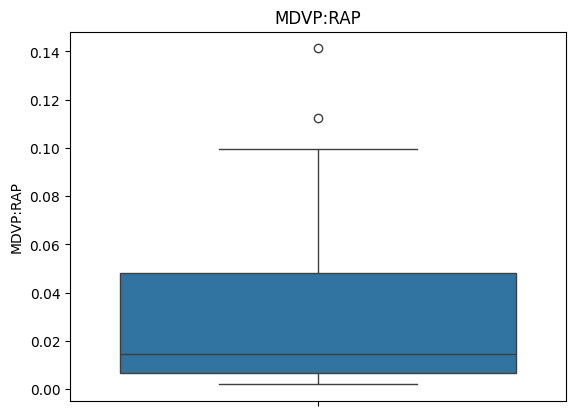

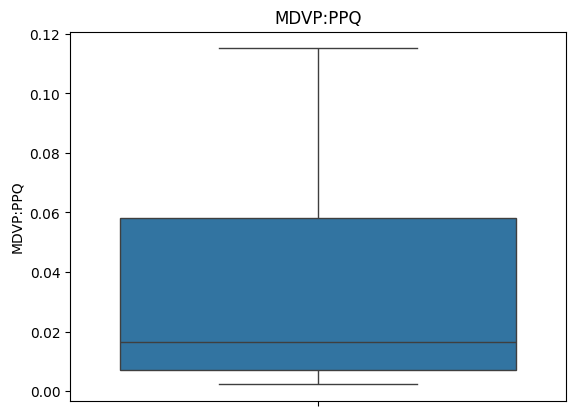

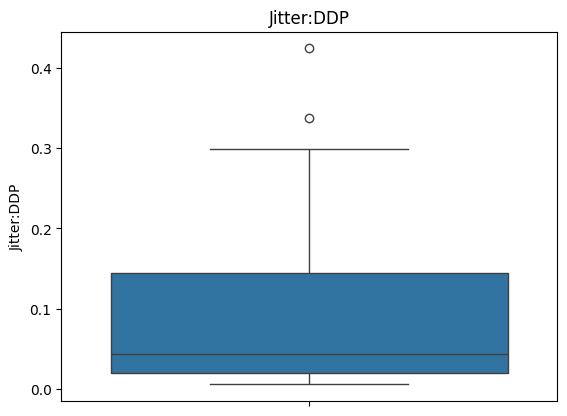

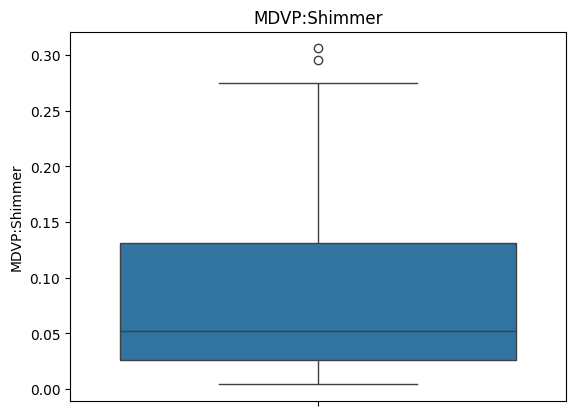

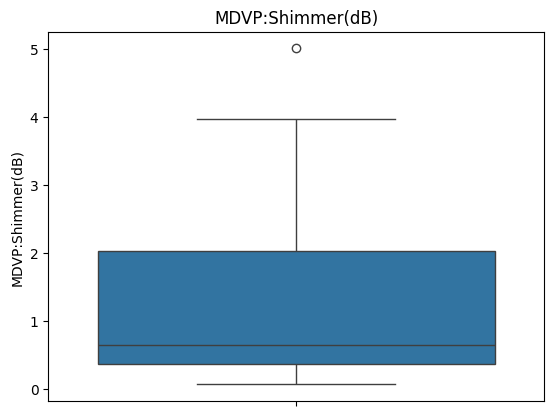

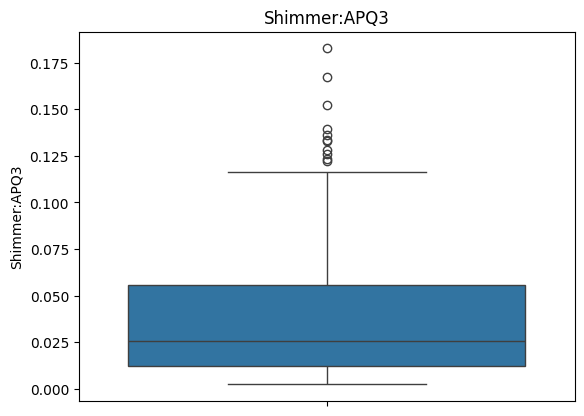

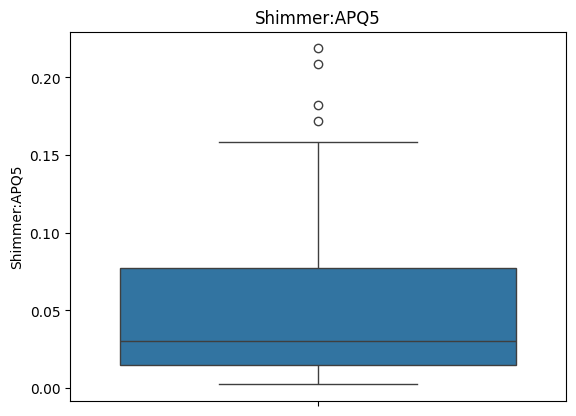

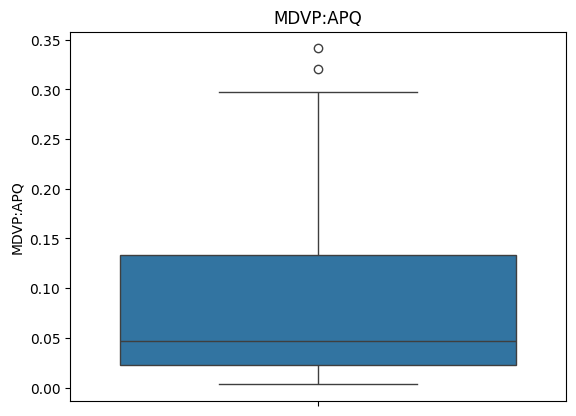

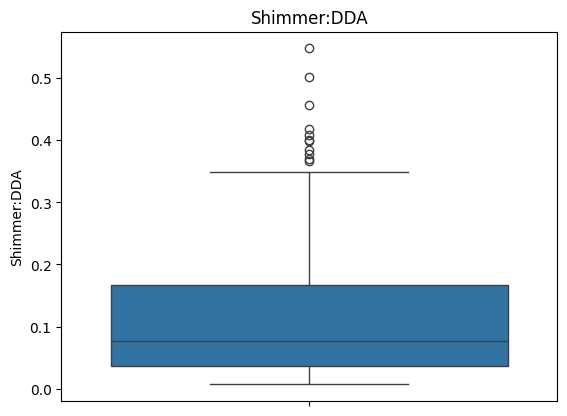

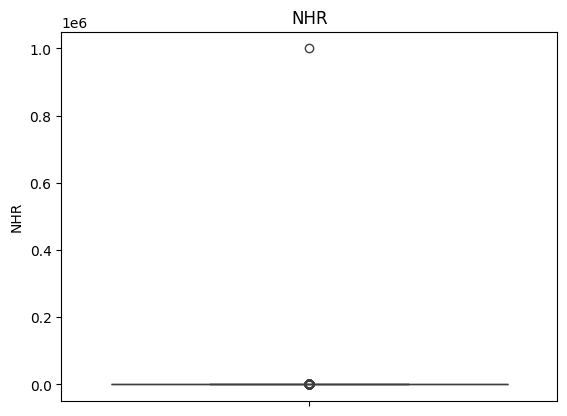

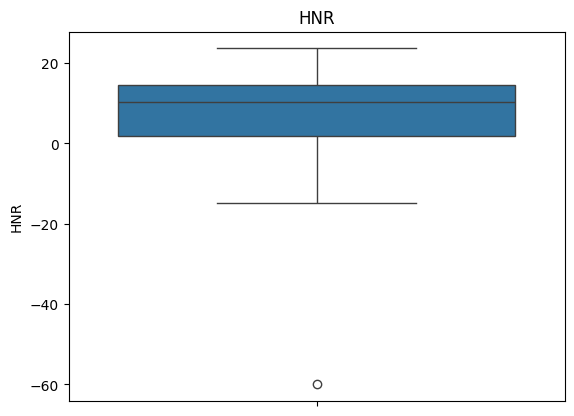

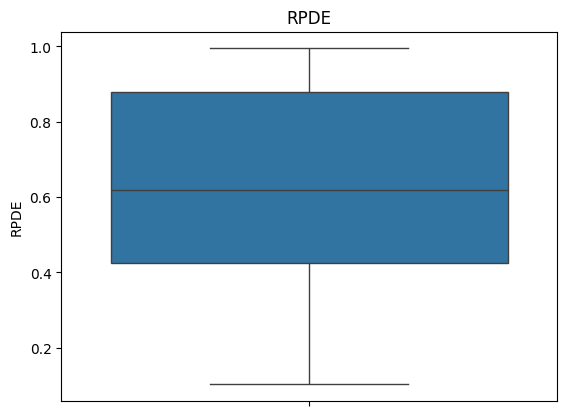

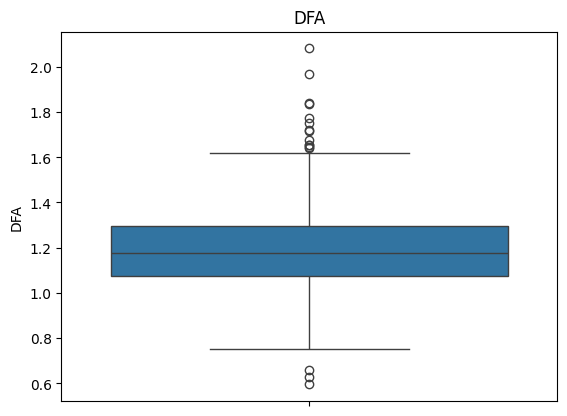

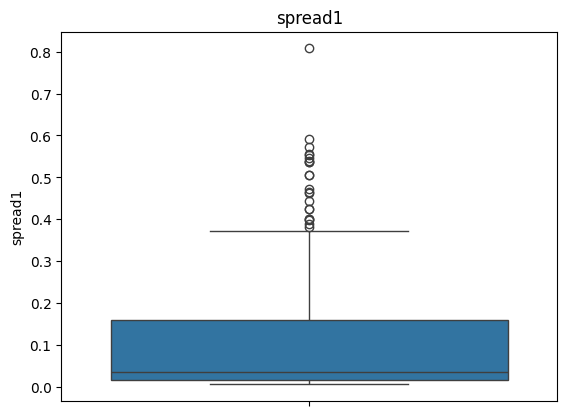

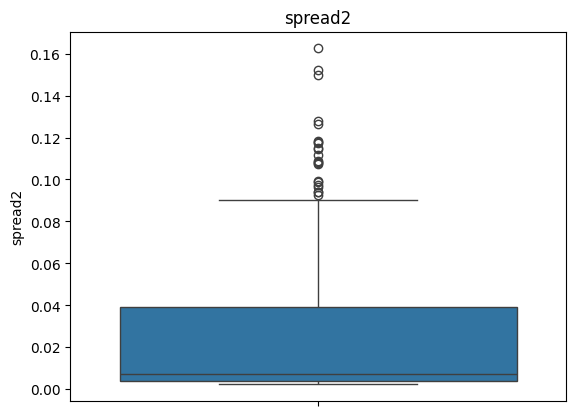

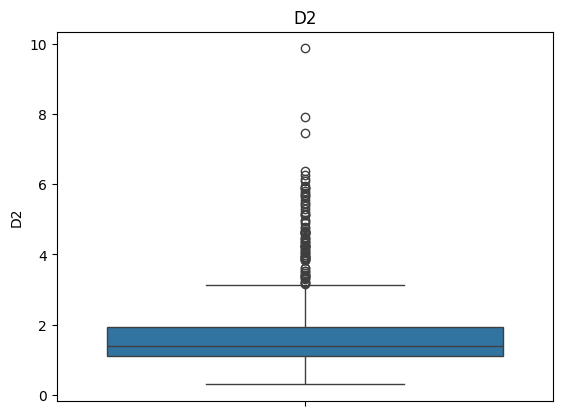

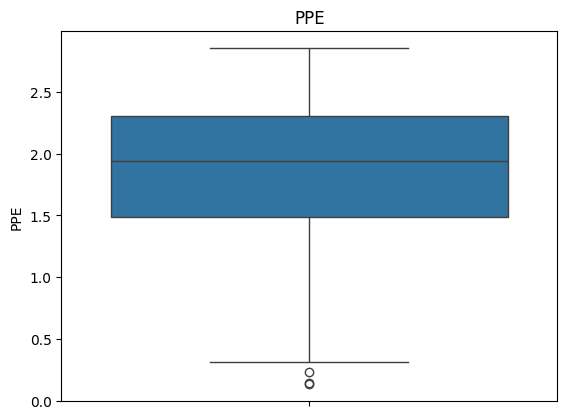

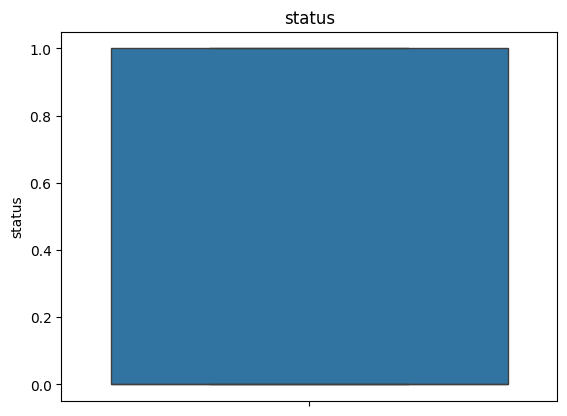

In [6]:
def boxtplot(col):
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

for i in list(df.columns[1:]):
    boxtplot(i)

In [82]:
x=temp_df.drop(columns=['status','subject'])
y=temp_df['status']

In [83]:
x.isnull().sum()

MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [84]:
#feature scaling

# Feature Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler((-1, 1))
x = scaler.fit_transform(x)
x

array([[-0.07098299,  1.        , -0.14892964, ...,  0.43551052,
        -0.85066962,  0.30580062],
       [-0.33513768, -0.27258034, -0.17289958, ..., -0.61444521,
        -0.81957023,  0.90166854],
       [-0.19771078, -0.27258034, -0.04012329, ..., -0.95861647,
        -0.54061301,  0.22566282],
       ...,
       [-0.74834122, -0.80683627, -0.51093465, ..., -0.99006542,
        -0.67913765,  0.39905138],
       [-0.74384162, -0.76024072, -0.51688582, ..., -0.98023025,
        -0.61532267,  0.71753351],
       [-0.70966973, -0.72598488, -0.46829983, ..., -0.98733122,
        -0.7805633 ,  0.37897493]], shape=(668, 22))

In [63]:
np.isnan(x).sum()

np.int64(0)

In [88]:
column=list(temp_df.columns[1:-1:])

In [89]:
column

['MDVP:Fo(Hz)',
 'MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'MDVP:PPQ',
 'Jitter:DDP',
 'MDVP:Shimmer',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'MDVP:APQ',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'RPDE',
 'DFA',
 'spread1',
 'spread2',
 'D2',
 'PPE']

In [91]:
d=pd.DataFrame(x,columns=column)
d.isnull().sum()

MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [96]:
d['subject']=temp_df['subject']
d=d[[ 'subject','MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']]

In [95]:
d.columns

Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE', 'subject'],
      dtype='object')

In [98]:
d['status']=temp_df['status']
d

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,Anna B,-0.070983,1.000000,-0.148930,0.297350,-0.151314,0.102446,0.682908,0.102446,-0.297704,-0.144080,-0.768406,-0.657885,-0.321456,-0.768406,-0.999998,0.431362,0.962208,0.202036,-0.324365,0.435511,-0.850670,0.305801,1
1,Anna B,-0.335138,-0.272580,-0.172900,0.093426,-0.155670,-0.070865,0.426115,-0.070865,-0.168589,-0.147545,-0.679388,-0.545140,-0.238122,-0.679388,-0.999999,0.527999,0.889039,-0.134223,-0.858556,-0.614445,-0.819570,0.901669,1
2,Anna B,-0.197711,-0.272580,-0.040123,-0.959830,-0.972630,-0.958083,-0.945009,-0.958083,-0.877982,-0.932300,-0.904316,-0.907312,-0.913742,-0.904316,-1.000000,0.783129,-0.604866,-0.501856,-0.968567,-0.958616,-0.540613,0.225663,1
3,Anna B,-0.270211,-0.367916,0.049314,-0.979620,-0.984241,-0.973908,-0.971633,-0.973908,-0.905835,-0.961543,-0.932055,-0.928819,-0.933928,-0.932055,-1.000000,0.824989,0.252006,-0.231517,-0.983088,-0.981560,-0.709703,0.431073,1
4,Anna B,-0.180395,-0.264946,-0.242367,-0.951661,-0.967728,-0.951115,-0.936007,-0.951115,-0.873578,-0.926223,-0.897171,-0.908293,-0.916323,-0.897171,-1.000000,0.834438,-0.368611,-0.300952,-0.923800,-0.959870,-0.759291,-0.115011,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VITO L,-0.732728,-0.788520,-0.510935,-0.895464,-0.867827,-0.902935,-0.868067,-0.902935,-0.741048,-0.838127,-0.813044,-0.790477,-0.739517,-0.813044,-1.000000,0.770747,-0.356885,-0.349615,-0.989498,-0.983320,-0.639987,0.275671,0
664,VITO L,-0.750763,-0.774503,-0.580129,-0.848183,-0.810505,-0.862418,-0.814594,-0.862418,-0.673880,-0.831269,-0.735852,-0.710775,-0.708014,-0.735852,-1.000000,0.596689,-0.273728,-0.437450,-0.974337,-0.978647,-0.776370,0.354592,0
665,VITO L,-0.748341,-0.806836,-0.510935,-0.802949,-0.760960,-0.826777,-0.751206,-0.826777,-0.577144,-0.738388,-0.679528,-0.645334,-0.607264,-0.679528,-1.000000,0.692959,-0.275990,-0.061706,-0.986291,-0.990065,-0.679138,0.399051,0
666,VITO L,-0.743842,-0.760241,-0.516886,-0.878839,-0.846621,-0.892282,-0.844330,-0.892282,-0.674678,-0.824563,-0.853510,-0.794850,-0.617884,-0.853510,-1.000000,0.755622,-0.227504,-0.349633,-0.968144,-0.980230,-0.615323,0.717534,0


In [100]:
d.isnull().sum()

subject             0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
status              0
dtype: int64

In [101]:
d.to_csv("data1.csv", index=False)

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_features = [
    'MDVP:Jitter(%)',
    'MDVP:Shimmer',
    'HNR',
    'RPDE',
    'D2',
    'PPE'
]

plot_df = temp_df.copy()
plot_df['Class'] = plot_df['status'].map({
    0: 'Healthy',
    1: "Parkinson's"
})

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, feature in zip(axes, plot_features):
    sns.violinplot(
        data=plot_df,
        x='Class',
        y=feature,
        hue='Class',
        palette=['#4C78A8', '#F58518'],
        inner='box',
        legend=False,
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(
    'healthy_vs_parkinsons_feature_distributions.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

NameError: name 'temp_df' is not defined

<Axes: xlabel='subject', ylabel='D2'>

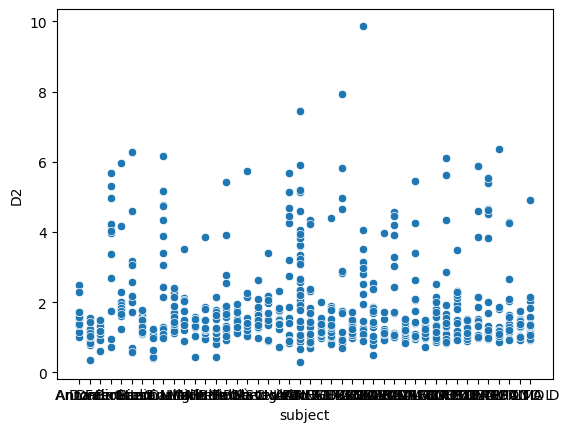

In [7]:
sns.scatterplot(data=df,x='subject',y='D2')

In [5]:
df

,name,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,D1ABNINSAC46F240120171756.wav,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,D2ABNINSAC46F240120171756.wav,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,VA1ABNINSAC46F240120171758.wav,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,VA2ABNINSAC46F240120171759.wav,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,VE1ABNINSAC46F240120171800.wav,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VI2VLIATFOO55M300320171247.wav,VITO L,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,VO1VLIATFOO55M300320171247.wav,VITO L,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,VO2VLIATFOO55M300320171248.wav,VITO L,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,VU1VLIATFOO55M300320171248.wav,VITO L,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


In [8]:
# ============================================================
# Create one-row-per-subject dataset using mean feature values
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load the recording-level dataset
# ------------------------------------------------------------
csv_path = "parkinsons_uci_style_dataset00.csv"

df = pd.read_csv(csv_path)

# Remove recording name if it exists
if "name" in df.columns:
    df = df.drop(columns=["name"])

# ------------------------------------------------------------
# 2. Handle missing feature values within each subject
#    Forward-fill and backward-fill only using that subject's
#    own recordings
# ------------------------------------------------------------
temp_df = (
    df.groupby("subject", group_keys=False)
      .apply(lambda group: group.ffill().bfill())
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Keep the feature columns used in the project
# ------------------------------------------------------------
feature_columns = [
    "MDVP:Fo(Hz)",
    "MDVP:Fhi(Hz)",
    "MDVP:Flo(Hz)",
    "MDVP:Jitter(%)",
    "MDVP:Jitter(Abs)",
    "MDVP:RAP",
    "MDVP:PPQ",
    "Jitter:DDP",
    "MDVP:Shimmer",
    "MDVP:Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "MDVP:APQ",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "spread1",
    "spread2",
    "D2",
    "PPE"
]

temp_df = temp_df[["subject"] + feature_columns + ["status"]]

# ------------------------------------------------------------
# 4. Confirm that every subject belongs to one class only
# ------------------------------------------------------------
class_check = temp_df.groupby("subject")["status"].nunique()

if class_check.max() > 1:
    raise ValueError(
        "At least one subject has recordings with different status labels."
    )

# ------------------------------------------------------------
# 5. Calculate mean value of every feature for each subject
# ------------------------------------------------------------
subject_mean_df = (
    temp_df
    .groupby("subject", as_index=False)
    .agg({
        **{feature: "mean" for feature in feature_columns},
        "status": "first"
    })
)

# ------------------------------------------------------------
# 6. Add readable class labels
# ------------------------------------------------------------
subject_mean_df["Class"] = subject_mean_df["status"].map({
    0: "Healthy",
    1: "Parkinson's"
})

# ------------------------------------------------------------
# 7. Arrange columns clearly
# ------------------------------------------------------------
subject_mean_df = subject_mean_df[
    ["subject"] + feature_columns + ["status", "Class"]
]

# ------------------------------------------------------------
# 8. Save the subject-level dataset
# ------------------------------------------------------------
subject_mean_df.to_csv(
    "subject_mean_dataset.csv",
    index=False
)

# ------------------------------------------------------------
# 9. Display results
# ------------------------------------------------------------
print("Original recording-level dataset shape:", temp_df.shape)
print("Subject-level mean dataset shape:", subject_mean_df.shape)

print("\nNumber of subjects in each class:")
print(subject_mean_df["Class"].value_counts())

print("\nFirst five rows of subject-level dataset:")
display(subject_mean_df.head())

print("\nMissing values:")
print(subject_mean_df.isnull().sum())

Original recording-level dataset shape: (668, 24)
Subject-level mean dataset shape: (44, 25)

Number of subjects in each class:
Class
Healthy        22
Parkinson's    22
Name: count, dtype: int64

First five rows of subject-level dataset:


,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,AGNESE P,222.793313,324.576964,159.135846,7.950438,0.000389,0.046850,0.052161,0.140551,0.151329,1.684690,0.080029,0.100532,0.132694,0.240086,0.649922,6.843314,0.688673,1.317478,0.161228,0.026428,1.691549,1.633562,0,Healthy
1,ANGELA C,168.007538,243.118272,141.772114,5.928838,0.000344,0.033018,0.040904,0.099053,0.099490,1.354947,0.044776,0.062629,0.110408,0.134329,1.184841,4.883795,0.684117,1.125635,0.065472,0.020219,1.284214,2.013497,0,Healthy
2,ANGELA G,182.734869,261.375197,144.624876,5.278911,0.000285,0.030709,0.035527,0.092126,0.072687,1.058070,0.033501,0.045315,0.078174,0.100504,1.259154,6.567323,0.634698,1.243269,0.092349,0.017141,1.470401,1.844134,0,Healthy
3,ANTONIETTA P,210.752981,279.793985,168.885970,4.851723,0.000240,0.028194,0.031621,0.084583,0.090913,1.163659,0.044820,0.049541,0.082138,0.134459,1.543292,5.436372,0.597381,1.172466,0.083039,0.022944,2.594087,1.701540,0,Healthy
4,ANTONIO C,133.493313,188.703455,96.382016,6.078879,0.000425,0.035671,0.040849,0.107014,0.101944,1.376836,0.046475,0.061713,0.108429,0.139425,2.533165,2.151210,0.731428,1.229174,0.107587,0.026484,1.258169,1.944451,0,Healthy



Missing values:
subject             0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      1
MDVP:Jitter(Abs)    1
MDVP:RAP            1
MDVP:PPQ            1
Jitter:DDP          1
MDVP:Shimmer        1
MDVP:Shimmer(dB)    1
Shimmer:APQ3        1
Shimmer:APQ5        1
MDVP:APQ            1
Shimmer:DDA         1
NHR                 0
HNR                 0
RPDE                1
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
status              0
Class               0
dtype: int64


In [11]:
# ============================================================
# Create one-row-per-subject dataset using mean feature values
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load the recording-level dataset
# ------------------------------------------------------------
csv_path = "parkinsons_uci_style_dataset00.csv"

df = pd.read_csv(csv_path)

# Remove recording name if it exists
if "name" in df.columns:
    df = df.drop(columns=["name"])

# ------------------------------------------------------------
# 2. Handle missing feature values within each subject
#    Forward-fill and backward-fill only using that subject's
#    own recordings
# ------------------------------------------------------------
temp_df = (
    df.groupby("subject", group_keys=False)
      .apply(lambda group: group.ffill().bfill())
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Keep the feature columns used in the project
# ------------------------------------------------------------
feature_columns = [
    "MDVP:Fo(Hz)",
    "MDVP:Fhi(Hz)",
    "MDVP:Flo(Hz)",
    "MDVP:Jitter(%)",
    "MDVP:Jitter(Abs)",
    "MDVP:RAP",
    "MDVP:PPQ",
    "Jitter:DDP",
    "MDVP:Shimmer",
    "MDVP:Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "MDVP:APQ",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "spread1",
    "spread2",
    "D2",
    "PPE"
]

temp_df = temp_df[["subject"] + feature_columns + ["status"]]

# ------------------------------------------------------------
# 4. Confirm that every subject belongs to one class only
# ------------------------------------------------------------
class_check = temp_df.groupby("subject")["status"].nunique()

if class_check.max() > 1:
    raise ValueError(
        "At least one subject has recordings with different status labels."
    )

# ------------------------------------------------------------
# 5. Calculate mean value of every feature for each subject
# ------------------------------------------------------------
subject_mean_df = (
    temp_df
    .groupby("subject", as_index=False)
    .agg({
        **{feature: "mean" for feature in feature_columns},
        "status": "first"
    })
)

# ------------------------------------------------------------
# 6. Add readable class labels
# ------------------------------------------------------------
subject_mean_df["Class"] = subject_mean_df["status"].map({
    0: "Healthy",
    1: "Parkinson's"
})

# ------------------------------------------------------------
# 7. Arrange columns clearly
# ------------------------------------------------------------
subject_mean_df = subject_mean_df[
    ["subject"] + feature_columns + ["status", "Class"]
]

# ------------------------------------------------------------
# 8. Save the subject-level dataset
# ------------------------------------------------------------
subject_mean_df.to_csv(
    "subject_mean_dataset.csv",
    index=False
)

# ------------------------------------------------------------
# 9. Display results
# ------------------------------------------------------------
print("Original recording-level dataset shape:", temp_df.shape)
print("Subject-level mean dataset shape:", subject_mean_df.shape)

print("\nNumber of subjects in each class:")
print(subject_mean_df["Class"].value_counts())

print("\nFirst five rows of subject-level dataset:")
display(subject_mean_df.head())

print("\nMissing values:")
print(subject_mean_df.isnull().sum())

Original recording-level dataset shape: (668, 24)
Subject-level mean dataset shape: (44, 25)

Number of subjects in each class:
Class
Healthy        22
Parkinson's    22
Name: count, dtype: int64

First five rows of subject-level dataset:


,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,AGNESE P,222.793313,324.576964,159.135846,7.950438,0.000389,0.046850,0.052161,0.140551,0.151329,1.684690,0.080029,0.100532,0.132694,0.240086,0.649922,6.843314,0.688673,1.317478,0.161228,0.026428,1.691549,1.633562,0,Healthy
1,ANGELA C,168.007538,243.118272,141.772114,5.928838,0.000344,0.033018,0.040904,0.099053,0.099490,1.354947,0.044776,0.062629,0.110408,0.134329,1.184841,4.883795,0.684117,1.125635,0.065472,0.020219,1.284214,2.013497,0,Healthy
2,ANGELA G,182.734869,261.375197,144.624876,5.278911,0.000285,0.030709,0.035527,0.092126,0.072687,1.058070,0.033501,0.045315,0.078174,0.100504,1.259154,6.567323,0.634698,1.243269,0.092349,0.017141,1.470401,1.844134,0,Healthy
3,ANTONIETTA P,210.752981,279.793985,168.885970,4.851723,0.000240,0.028194,0.031621,0.084583,0.090913,1.163659,0.044820,0.049541,0.082138,0.134459,1.543292,5.436372,0.597381,1.172466,0.083039,0.022944,2.594087,1.701540,0,Healthy
4,ANTONIO C,133.493313,188.703455,96.382016,6.078879,0.000425,0.035671,0.040849,0.107014,0.101944,1.376836,0.046475,0.061713,0.108429,0.139425,2.533165,2.151210,0.731428,1.229174,0.107587,0.026484,1.258169,1.944451,0,Healthy



Missing values:
subject             0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      1
MDVP:Jitter(Abs)    1
MDVP:RAP            1
MDVP:PPQ            1
Jitter:DDP          1
MDVP:Shimmer        1
MDVP:Shimmer(dB)    1
Shimmer:APQ3        1
Shimmer:APQ5        1
MDVP:APQ            1
Shimmer:DDA         1
NHR                 0
HNR                 0
RPDE                1
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
status              0
Class               0
dtype: int64


In [10]:
df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VITO L,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,VITO L,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,VITO L,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,VITO L,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


In [12]:
subject_mean_dataset

NameError: name 'subject_mean_dataset' is not defined

In [13]:
subject_mean_df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,AGNESE P,222.793313,324.576964,159.135846,7.950438,0.000389,0.046850,0.052161,0.140551,0.151329,1.684690,0.080029,0.100532,0.132694,0.240086,0.649922,6.843314,0.688673,1.317478,0.161228,0.026428,1.691549,1.633562,0,Healthy
1,ANGELA C,168.007538,243.118272,141.772114,5.928838,0.000344,0.033018,0.040904,0.099053,0.099490,1.354947,0.044776,0.062629,0.110408,0.134329,1.184841,4.883795,0.684117,1.125635,0.065472,0.020219,1.284214,2.013497,0,Healthy
2,ANGELA G,182.734869,261.375197,144.624876,5.278911,0.000285,0.030709,0.035527,0.092126,0.072687,1.058070,0.033501,0.045315,0.078174,0.100504,1.259154,6.567323,0.634698,1.243269,0.092349,0.017141,1.470401,1.844134,0,Healthy
3,ANTONIETTA P,210.752981,279.793985,168.885970,4.851723,0.000240,0.028194,0.031621,0.084583,0.090913,1.163659,0.044820,0.049541,0.082138,0.134459,1.543292,5.436372,0.597381,1.172466,0.083039,0.022944,2.594087,1.701540,0,Healthy
4,ANTONIO C,133.493313,188.703455,96.382016,6.078879,0.000425,0.035671,0.040849,0.107014,0.101944,1.376836,0.046475,0.061713,0.108429,0.139425,2.533165,2.151210,0.731428,1.229174,0.107587,0.026484,1.258169,1.944451,0,Healthy
5,Anna B,194.698207,221.140644,163.500014,2.816136,0.000147,0.016131,0.019305,0.048393,0.033447,0.500667,0.010993,0.014891,0.031213,0.032978,0.137172,14.851718,0.592417,1.142161,0.045288,0.016654,1.614612,1.830243,1,Parkinson's
6,Antonia G,182.995957,248.899396,94.834825,5.004539,0.000336,0.028926,0.034827,0.086779,0.073887,1.204142,0.036861,0.048144,0.079369,0.110584,2.171794,2.864310,0.780736,1.397393,0.296498,0.054702,1.019825,1.870834,1,Parkinson's
7,BRIGIDA C,210.290366,257.663311,182.518884,4.998303,0.000243,0.028122,0.033606,0.084366,0.078397,1.121196,0.035213,0.048730,0.082146,0.105639,0.656045,8.764301,0.578346,1.119059,0.052109,0.016052,2.570584,1.874427,0,Healthy
8,Daria L,188.727910,210.110829,112.985075,3.068962,0.000186,0.017384,0.021157,0.052152,0.036218,0.748327,0.014707,0.018949,0.036464,0.044120,0.163985,11.990953,0.623822,1.210348,0.178010,0.033456,1.242195,1.608029,1,Parkinson's
9,Domenico C,130.447998,145.454125,95.330206,1.166101,0.000087,0.006540,0.007575,0.019619,0.028702,0.307001,0.015466,0.017335,0.021738,0.046399,0.435314,14.290705,0.521340,1.030956,0.067597,0.022482,3.482383,1.022816,1,Parkinson's


In [14]:
import pandas as pd

# Set a fixed seed so you can reproduce the same random selection
random_seed = 42

# Separate Healthy and Parkinson's subjects
healthy_df = subject_mean_df[
    subject_mean_df["status"] == 0
]

parkinsons_df = subject_mean_df[
    subject_mean_df["status"] == 1
]

# Check that at least 10 subjects exist in each class
if len(healthy_df) < 10 or len(parkinsons_df) < 10:
    raise ValueError(
        f"Not enough subjects. Healthy: {len(healthy_df)}, "
        f"Parkinson's: {len(parkinsons_df)}"
    )

# Randomly select 10 subjects from each class
selected_healthy = healthy_df.sample(
    n=10,
    random_state=random_seed
)

selected_parkinsons = parkinsons_df.sample(
    n=10,
    random_state=random_seed
)

# Combine them into one balanced subject-level dataset
balanced_subject_df = pd.concat(
    [selected_healthy, selected_parkinsons],
    ignore_index=True
)

# Randomly shuffle the final 20 rows
balanced_subject_df = balanced_subject_df.sample(
    frac=1,
    random_state=random_seed
).reset_index(drop=True)

# Save it
balanced_subject_df.to_csv(
    "balanced_10_healthy_10_parkinsons_subjects.csv",
    index=False
)

print("Final dataset shape:", balanced_subject_df.shape)

print("\nClass distribution:")
print(balanced_subject_df["Class"].value_counts())

display(balanced_subject_df.head())

Final dataset shape: (20, 25)

Class distribution:
Class
Healthy        10
Parkinson's    10
Name: count, dtype: int64


,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,AGNESE P,222.793313,324.576964,159.135846,7.950438,0.000389,0.046850,0.052161,0.140551,0.151329,1.684690,0.080029,0.100532,0.132694,0.240086,0.649922,6.843314,0.688673,1.317478,0.161228,0.026428,1.691549,1.633562,0,Healthy
1,Mario B,114.446115,128.325986,81.323372,2.056239,0.000189,0.010843,0.014182,0.032529,0.047083,0.835167,0.017704,0.028695,0.066552,0.053112,0.230084,10.128963,0.615725,1.062796,0.092539,0.020557,1.307036,1.599896,1,Parkinson's
2,Giovanni N,113.152423,125.881779,98.763078,1.758040,0.000164,0.009467,0.011605,0.028402,0.038932,0.644847,0.018527,0.023759,0.036028,0.055581,0.100562,14.559491,0.546007,1.145281,0.064318,0.020288,2.663468,1.677518,1,Parkinson's
3,MARIACRISTINA P,180.467567,227.389591,157.707049,4.329592,0.000236,0.025080,0.028832,0.075239,0.057499,0.928352,0.023305,0.034349,0.067377,0.069915,0.767833,8.127362,0.583465,1.215512,0.052243,0.013148,2.136943,2.074657,0,Healthy
4,ANTONIETTA P,210.752981,279.793985,168.885970,4.851723,0.000240,0.028194,0.031621,0.084583,0.090913,1.163659,0.044820,0.049541,0.082138,0.134459,1.543292,5.436372,0.597381,1.172466,0.083039,0.022944,2.594087,1.701540,0,Healthy


In [16]:
balanced_subject_df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,AGNESE P,222.793313,324.576964,159.135846,7.950438,0.000389,0.046850,0.052161,0.140551,0.151329,1.684690,0.080029,0.100532,0.132694,0.240086,0.649922,6.843314,0.688673,1.317478,0.161228,0.026428,1.691549,1.633562,0,Healthy
1,Mario B,114.446115,128.325986,81.323372,2.056239,0.000189,0.010843,0.014182,0.032529,0.047083,0.835167,0.017704,0.028695,0.066552,0.053112,0.230084,10.128963,0.615725,1.062796,0.092539,0.020557,1.307036,1.599896,1,Parkinson's
2,Giovanni N,113.152423,125.881779,98.763078,1.758040,0.000164,0.009467,0.011605,0.028402,0.038932,0.644847,0.018527,0.023759,0.036028,0.055581,0.100562,14.559491,0.546007,1.145281,0.064318,0.020288,2.663468,1.677518,1,Parkinson's
3,MARIACRISTINA P,180.467567,227.389591,157.707049,4.329592,0.000236,0.025080,0.028832,0.075239,0.057499,0.928352,0.023305,0.034349,0.067377,0.069915,0.767833,8.127362,0.583465,1.215512,0.052243,0.013148,2.136943,2.074657,0,Healthy
4,ANTONIETTA P,210.752981,279.793985,168.885970,4.851723,0.000240,0.028194,0.031621,0.084583,0.090913,1.163659,0.044820,0.049541,0.082138,0.134459,1.543292,5.436372,0.597381,1.172466,0.083039,0.022944,2.594087,1.701540,0,Healthy
5,BRIGIDA C,210.290366,257.663311,182.518884,4.998303,0.000243,0.028122,0.033606,0.084366,0.078397,1.121196,0.035213,0.048730,0.082146,0.105639,0.656045,8.764301,0.578346,1.119059,0.052109,0.016052,2.570584,1.874427,0,Healthy
6,Nicola M,156.435171,203.144575,100.453673,3.142301,0.000224,0.017738,0.021010,0.053213,0.046632,0.849168,0.019818,0.024191,0.040589,0.059455,0.043601,15.069164,0.682236,1.280052,0.185204,0.038255,1.312876,1.710000,1,Parkinson's
7,ANGELA C,168.007538,243.118272,141.772114,5.928838,0.000344,0.033018,0.040904,0.099053,0.099490,1.354947,0.044776,0.062629,0.110408,0.134329,1.184841,4.883795,0.684117,1.125635,0.065472,0.020219,1.284214,2.013497,0,Healthy
8,Domenico C,130.447998,145.454125,95.330206,1.166101,0.000087,0.006540,0.007575,0.019619,0.028702,0.307001,0.015466,0.017335,0.021738,0.046399,0.435314,14.290705,0.521340,1.030956,0.067597,0.022482,3.482383,1.022816,1,Parkinson's
9,Vito L,140.912676,191.721786,90.086432,3.655995,0.000265,0.020233,0.024980,0.060700,0.082944,1.292982,0.041688,0.048145,0.080388,0.125065,62500.204331,6.976611,0.611054,1.102168,0.165547,0.040322,2.525630,1.394116,1,Parkinson's


In [19]:
balanced_subject_df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,AGNESE P,222.793313,324.576964,159.135846,7.950438,0.000389,0.046850,0.052161,0.140551,0.151329,1.684690,0.080029,0.100532,0.132694,0.240086,0.649922,6.843314,0.688673,1.317478,0.161228,0.026428,1.691549,1.633562,0,Healthy
1,Mario B,114.446115,128.325986,81.323372,2.056239,0.000189,0.010843,0.014182,0.032529,0.047083,0.835167,0.017704,0.028695,0.066552,0.053112,0.230084,10.128963,0.615725,1.062796,0.092539,0.020557,1.307036,1.599896,1,Parkinson's
2,Giovanni N,113.152423,125.881779,98.763078,1.758040,0.000164,0.009467,0.011605,0.028402,0.038932,0.644847,0.018527,0.023759,0.036028,0.055581,0.100562,14.559491,0.546007,1.145281,0.064318,0.020288,2.663468,1.677518,1,Parkinson's
3,MARIACRISTINA P,180.467567,227.389591,157.707049,4.329592,0.000236,0.025080,0.028832,0.075239,0.057499,0.928352,0.023305,0.034349,0.067377,0.069915,0.767833,8.127362,0.583465,1.215512,0.052243,0.013148,2.136943,2.074657,0,Healthy
4,ANTONIETTA P,210.752981,279.793985,168.885970,4.851723,0.000240,0.028194,0.031621,0.084583,0.090913,1.163659,0.044820,0.049541,0.082138,0.134459,1.543292,5.436372,0.597381,1.172466,0.083039,0.022944,2.594087,1.701540,0,Healthy
5,BRIGIDA C,210.290366,257.663311,182.518884,4.998303,0.000243,0.028122,0.033606,0.084366,0.078397,1.121196,0.035213,0.048730,0.082146,0.105639,0.656045,8.764301,0.578346,1.119059,0.052109,0.016052,2.570584,1.874427,0,Healthy
6,Nicola M,156.435171,203.144575,100.453673,3.142301,0.000224,0.017738,0.021010,0.053213,0.046632,0.849168,0.019818,0.024191,0.040589,0.059455,0.043601,15.069164,0.682236,1.280052,0.185204,0.038255,1.312876,1.710000,1,Parkinson's
7,ANGELA C,168.007538,243.118272,141.772114,5.928838,0.000344,0.033018,0.040904,0.099053,0.099490,1.354947,0.044776,0.062629,0.110408,0.134329,1.184841,4.883795,0.684117,1.125635,0.065472,0.020219,1.284214,2.013497,0,Healthy
8,Domenico C,130.447998,145.454125,95.330206,1.166101,0.000087,0.006540,0.007575,0.019619,0.028702,0.307001,0.015466,0.017335,0.021738,0.046399,0.435314,14.290705,0.521340,1.030956,0.067597,0.022482,3.482383,1.022816,1,Parkinson's
9,Vito L,140.912676,191.721786,90.086432,3.655995,0.000265,0.020233,0.024980,0.060700,0.082944,1.292982,0.041688,0.048145,0.080388,0.125065,62500.204331,6.976611,0.611054,1.102168,0.165547,0.040322,2.525630,1.394116,1,Parkinson's


<Axes: xlabel='subject', ylabel='MDVP:Jitter(%)'>

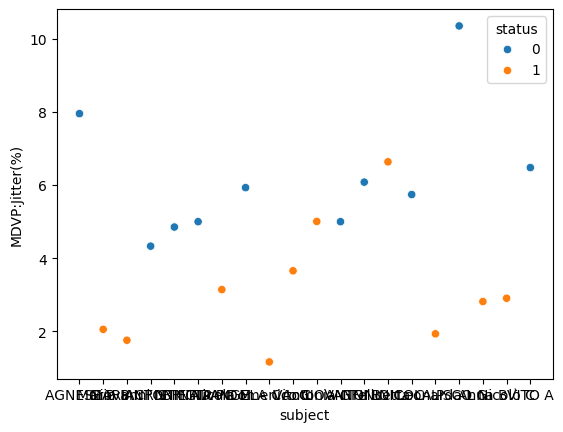

In [21]:
sns.scatterplot(data=balanced_subject_df,x='subject',y='MDVP:Jitter(%)',hue='status')

In [22]:
df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VITO L,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,VITO L,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,VITO L,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,VITO L,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


In [26]:
temp=df.sample(20).copy()
temp

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
120,Luigi B,90.790648,100.326385,60.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.600867,2.212213,NaN,0.786507,0.081720,0.054552,1.218351,2.085334,1
53,Felicetta C,238.868267,351.380567,194.940575,6.092339,0.000273,0.036723,0.037249,0.110168,0.066867,0.835390,0.021247,0.032508,0.075833,0.063740,0.081075,10.911131,0.677199,1.359761,0.156827,0.032810,1.247531,1.376831,1
224,Roberto R,119.885176,141.065749,113.921055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.057550,12.399560,NaN,1.146144,0.027867,0.006421,1.264168,2.146587,1
522,LUIGI P,102.777604,105.679905,91.999701,1.851571,0.000180,0.011027,0.011840,0.033081,0.057245,0.645582,0.028359,0.035645,0.050543,0.085076,0.153443,8.140532,0.399682,1.279831,0.018871,0.005040,1.343259,2.051920,0
364,ANGELA G,180.451339,190.488126,158.340949,1.236422,0.000068,0.007335,0.008308,0.022006,0.032064,0.390386,0.016091,0.019796,0.029159,0.048273,0.067268,11.721900,0.382405,1.225929,0.016274,0.003627,1.774350,1.553515,0
515,LUIGI P,153.210655,372.274743,75.159866,12.299306,0.000747,0.071007,0.085755,0.213021,0.207516,2.511233,0.088527,0.122289,0.240033,0.265581,5.256449,-7.206924,0.917886,1.277148,0.308639,0.064701,1.032260,2.645189,0
54,Felicetta C,234.041964,247.032537,117.259196,4.985057,0.000208,0.029077,0.032615,0.087230,0.057951,0.745350,0.027306,0.038429,0.049807,0.081917,0.090573,10.429995,0.615395,1.258329,0.132645,0.026602,1.923756,0.947142,1
261,Ugo B,168.381967,187.215654,160.180783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006616,21.794120,NaN,0.958380,0.013970,0.004818,1.765456,1.817847,1
214,Roberto L,174.159718,178.761296,166.790186,0.608146,0.000035,0.003790,0.003875,0.011371,0.015449,0.133841,0.008968,0.007811,0.011664,0.026904,0.024311,16.141970,0.723435,1.191336,0.014300,0.003100,1.417307,2.215650,1
170,Nicola S,106.066798,146.886425,70.941467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.312439,-1.180793,NaN,1.492068,0.172629,0.088013,0.910150,2.747740,1


In [27]:
temp['status'].value_counts()

status
1    11
0     9
Name: count, dtype: int64

In [31]:
df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VITO L,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,VITO L,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,VITO L,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,VITO L,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


In [33]:
import pandas as pd

# ------------------------------------------------------------
# Feature columns only
# ------------------------------------------------------------
feature_columns = temp_df.columns.drop(["subject", "status"])

# Confirm that each subject has one fixed class label
assert temp_df.groupby("subject")["status"].nunique().max() == 1

# ------------------------------------------------------------
# One row per subject: maximum value of every feature
# ------------------------------------------------------------
subject_max_df = (
    temp_df
    .groupby("subject", as_index=False)
    .agg({
        **{feature: "max" for feature in feature_columns},
        "status": "first"
    })
)

# Add readable class label
subject_max_df["Class"] = subject_max_df["status"].map({
    0: "Healthy",
    1: "Parkinson's"
})

# Arrange columns
subject_max_df = subject_max_df[
    ["subject"] + list(feature_columns) + ["status", "Class"]
]

# Save the subject-level maximum dataset
subject_max_df.to_csv(
    "subject_max_feature_dataset.csv",
    index=False
)

print("Number of subjects:", len(subject_max_df))
print("\nClass distribution:")
print(subject_max_df["Class"].value_counts())

display(subject_max_df.head())

Number of subjects: 44

Class distribution:
Class
Healthy        22
Parkinson's    22
Name: count, dtype: int64


,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,AGNESE P,291.675223,398.994190,218.813397,18.335768,0.000909,0.112373,0.111663,0.337119,0.267287,3.133164,0.133348,0.182029,0.254423,0.400044,2.498060,14.491072,0.964517,1.749650,0.370584,0.059227,4.336192,2.363293,0,Healthy
1,ANGELA C,175.728491,370.130598,164.874438,12.274109,0.000707,0.068409,0.085181,0.205226,0.185459,2.631161,0.081890,0.118590,0.230708,0.245671,4.953325,14.664873,0.972653,1.375462,0.189484,0.056823,2.005293,2.584101,0,Healthy
2,ANGELA G,198.043778,398.994190,191.591613,12.697062,0.000703,0.073041,0.087064,0.219122,0.147748,2.136841,0.064256,0.093708,0.176567,0.192768,5.519785,22.440090,0.976423,1.514524,0.207408,0.043969,4.404969,2.800470,0,Healthy
3,ANTONIETTA P,250.469627,398.994190,225.225119,11.698661,0.000582,0.067793,0.080706,0.203379,0.270106,2.647445,0.152389,0.129072,0.190062,0.457166,8.779775,16.710350,0.979155,1.545634,0.274322,0.061917,7.920532,2.716102,0,Healthy
4,ANTONIO C,152.720449,380.976252,135.475729,13.756755,0.000939,0.080365,0.095212,0.241096,0.177136,2.356543,0.075375,0.108734,0.205304,0.226125,11.862680,12.874654,0.950794,1.564206,0.289635,0.053927,1.718527,2.760311,0,Healthy


In [34]:
subject_max_df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,AGNESE P,291.675223,398.994190,218.813397,18.335768,0.000909,0.112373,0.111663,0.337119,0.267287,3.133164,0.133348,0.182029,0.254423,0.400044,2.498060,14.491072,0.964517,1.749650,0.370584,0.059227,4.336192,2.363293,0,Healthy
1,ANGELA C,175.728491,370.130598,164.874438,12.274109,0.000707,0.068409,0.085181,0.205226,0.185459,2.631161,0.081890,0.118590,0.230708,0.245671,4.953325,14.664873,0.972653,1.375462,0.189484,0.056823,2.005293,2.584101,0,Healthy
2,ANGELA G,198.043778,398.994190,191.591613,12.697062,0.000703,0.073041,0.087064,0.219122,0.147748,2.136841,0.064256,0.093708,0.176567,0.192768,5.519785,22.440090,0.976423,1.514524,0.207408,0.043969,4.404969,2.800470,0,Healthy
3,ANTONIETTA P,250.469627,398.994190,225.225119,11.698661,0.000582,0.067793,0.080706,0.203379,0.270106,2.647445,0.152389,0.129072,0.190062,0.457166,8.779775,16.710350,0.979155,1.545634,0.274322,0.061917,7.920532,2.716102,0,Healthy
4,ANTONIO C,152.720449,380.976252,135.475729,13.756755,0.000939,0.080365,0.095212,0.241096,0.177136,2.356543,0.075375,0.108734,0.205304,0.226125,11.862680,12.874654,0.950794,1.564206,0.289635,0.053927,1.718527,2.760311,0,Healthy
5,Anna B,211.500233,398.994190,202.984243,14.113187,0.000688,0.078772,0.097230,0.236317,0.129743,2.182855,0.031249,0.051539,0.132004,0.093747,1.031038,23.054922,0.977820,1.488822,0.276502,0.117322,2.495142,2.720566,1,Parkinson's
6,Antonia G,215.478269,329.748875,198.348076,14.025576,0.001200,0.082976,0.106126,0.248927,0.261316,3.702964,0.139138,0.208440,0.341229,0.417415,10.045353,13.237303,0.970083,1.834385,0.590829,0.126241,1.539693,2.769402,1,Parkinson's
7,BRIGIDA C,238.310549,394.411351,234.518392,11.105693,0.000540,0.060538,0.075041,0.181613,0.168445,2.251468,0.076094,0.105703,0.183389,0.228281,3.436121,21.314801,0.946053,1.420659,0.150020,0.038440,9.869837,2.754198,0,Healthy
8,Daria L,216.607127,242.788666,205.342806,13.297384,0.000949,0.074710,0.094818,0.224131,0.124743,3.147509,0.054731,0.070494,0.137558,0.164192,1.099458,20.434886,0.886105,1.383363,0.545741,0.107404,1.487519,2.716338,1,Parkinson's
9,Domenico C,145.880688,156.522248,113.921055,2.057220,0.000153,0.011055,0.014149,0.033166,0.052770,0.502994,0.029974,0.032701,0.038410,0.089922,4.332955,23.650742,0.717805,1.505231,0.355474,0.114854,5.687981,2.299962,1,Parkinson's


In [47]:
import pandas as pd

# Set a fixed seed so you can reproduce the same random selection
random_seed = 40

# Separate Healthy and Parkinson's subjects
healthy_df = subject_mean_df[
    subject_mean_df["status"] == 0
]

parkinsons_df = subject_mean_df[
    subject_mean_df["status"] == 1
]

# Check that at least 10 subjects exist in each class
if len(healthy_df) < 10 or len(parkinsons_df) < 10:
    raise ValueError(
        f"Not enough subjects. Healthy: {len(healthy_df)}, "
        f"Parkinson's: {len(parkinsons_df)}"
    )

# Randomly select 10 subjects from each class
selected_healthy = healthy_df.sample(
    n=10,
    random_state=random_seed
)

selected_parkinsons = parkinsons_df.sample(
    n=10,
    random_state=random_seed
)

# Combine them into one balanced subject-level dataset
balanced_subject_df = pd.concat(
    [selected_healthy, selected_parkinsons],
    ignore_index=True
)

# Randomly shuffle the final 20 rows
balanced_subject_df = balanced_subject_df.sample(
    frac=1,
    random_state=random_seed
).reset_index(drop=True)

# Save it
balanced_subject_df.to_csv(
    "balanced_10_healthy_10_parkinsons_subjects.csv",
    index=False
)

print("Final dataset shape:", balanced_subject_df.shape)

print("\nClass distribution:")
print(balanced_subject_df["Class"].value_counts())

display(balanced_subject_df.head())

Final dataset shape: (20, 25)

Class distribution:
Class
Healthy        10
Parkinson's    10
Name: count, dtype: int64


,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,GRAZIA G,169.195290,267.587541,116.797794,6.565587,0.000368,0.038367,0.043335,0.115100,0.179641,1.732914,0.095517,0.112770,0.149059,0.286550,1.162467,2.754222,0.685107,1.176641,0.125341,0.033982,1.165314,1.873168,0,Healthy
1,Lucia R,203.603296,221.349482,167.380863,2.260138,0.000121,0.012416,0.015980,0.037249,0.042040,0.709197,0.017751,0.020289,0.036966,0.053253,0.198263,10.982752,0.456163,1.133945,0.032316,0.010693,1.672886,1.713991,1,Parkinson's
2,Felicetta C,209.409906,269.322508,157.185512,6.633528,0.000318,0.038240,0.044871,0.114720,0.083544,0.956735,0.033761,0.048298,0.092424,0.101282,1.839702,7.986221,0.666093,1.207273,0.089354,0.023690,2.417461,1.360210,1,Parkinson's
3,GIOVANNI B,166.805781,255.037462,118.201356,4.997999,0.000308,0.029072,0.034081,0.087216,0.082166,1.156300,0.037869,0.049283,0.084514,0.113607,1.133670,4.911636,0.553331,1.233708,0.102946,0.023139,2.468454,1.328629,0,Healthy
4,AGNESE P,222.793313,324.576964,159.135846,7.950438,0.000389,0.046850,0.052161,0.140551,0.151329,1.684690,0.080029,0.100532,0.132694,0.240086,0.649922,6.843314,0.688673,1.317478,0.161228,0.026428,1.691549,1.633562,0,Healthy


In [40]:
balanced_subject_df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status,Class
0,GRAZIA G,193.795106,378.781991,159.258209,13.792626,0.000811,0.080468,0.090910,0.241405,0.237713,2.390905,0.136167,0.158420,0.216718,0.408500,3.059453,13.259058,0.973564,1.515101,0.340932,0.072525,1.508450,2.601456,0,Healthy
1,Lucia R,203.603296,221.349482,167.380863,2.260138,0.000121,0.012416,0.015980,0.037249,0.042040,0.709197,0.017751,0.020289,0.036966,0.053253,0.198263,10.982752,0.456163,1.133945,0.032316,0.010693,1.672886,1.713991,1,Parkinson's
2,Felicetta C,209.409906,269.322508,157.185512,6.633528,0.000318,0.038240,0.044871,0.114720,0.083544,0.956735,0.033761,0.048298,0.092424,0.101282,1.839702,7.986221,0.666093,1.207273,0.089354,0.023690,2.417461,1.360210,1,Parkinson's
3,GIOVANNI B,229.284263,398.994190,178.761296,10.483004,0.000668,0.061310,0.071439,0.183930,0.176309,2.513057,0.072017,0.108757,0.211497,0.216051,5.325959,21.562916,0.961363,1.655743,0.321719,0.053801,4.567659,2.258286,0,Healthy
4,AGNESE P,291.675223,398.994190,218.813397,18.335768,0.000909,0.112373,0.111663,0.337119,0.267287,3.133164,0.133348,0.182029,0.254423,0.400044,2.498060,14.491072,0.964517,1.749650,0.370584,0.059227,4.336192,2.363293,0,Healthy
5,Vito S,161.907656,192.005029,140.893490,3.051923,0.000242,0.017156,0.020875,0.051469,0.050149,0.837156,0.020923,0.029021,0.057208,0.062770,0.299153,13.471118,0.528350,1.120790,0.066762,0.019892,2.497335,1.793414,1,Parkinson's
6,Roberto R,130.486613,149.672078,117.895316,2.896374,0.000204,0.016133,0.019572,0.048399,0.065769,0.737572,0.030119,0.036925,0.060802,0.090356,0.235249,11.746570,0.641628,1.108194,0.031955,0.011073,1.547772,2.092008,1,Parkinson's
7,Ugo B,166.699474,208.984077,143.128336,3.917731,0.000249,0.020828,0.028735,0.062484,0.063351,0.997785,0.030648,0.033683,0.063524,0.091945,0.232087,15.003990,0.622966,1.123810,0.057546,0.022104,1.508070,1.829824,1,Parkinson's
8,PORCELLI A,176.206136,247.032537,128.612816,12.357457,0.000954,0.070257,0.083815,0.210770,0.190677,2.701251,0.075513,0.119725,0.241914,0.226538,3.572037,18.872389,0.956045,1.462779,0.342053,0.040530,5.881357,2.702521,0,Healthy
9,Mario B,114.446115,128.325986,81.323372,2.056239,0.000189,0.010843,0.014182,0.032529,0.047083,0.835167,0.017704,0.028695,0.066552,0.053112,0.230084,10.128963,0.615725,1.062796,0.092539,0.020557,1.307036,1.599896,1,Parkinson's


In [44]:
df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VITO L,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,VITO L,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,VITO L,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,VITO L,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


In [51]:
df[df['subject']=='GILDA C']

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
415,GILDA C,172.733229,398.994190,77.362219,8.926542,0.000536,0.051971,0.060415,0.155912,0.136768,2.296478,0.066209,0.090474,0.152066,0.198627,2.362856,-3.734373,0.946366,1.247211,0.236787,0.042761,0.490626,2.084766,0
416,GILDA C,175.753411,398.994190,77.362219,10.098284,0.000607,0.059587,0.068258,0.178761,0.140808,2.256066,0.066545,0.094344,0.161515,0.199634,2.420778,-3.839550,0.960471,1.265657,0.212839,0.040215,0.959372,2.041232,0
417,GILDA C,233.090262,398.994190,77.362219,10.027464,0.000433,0.057383,0.065539,0.172149,0.176641,3.181210,0.093181,0.115409,0.158513,0.279544,3.194985,-5.044688,0.904578,1.423429,0.464780,0.072339,0.874606,1.317667,0
418,GILDA C,220.091390,398.994190,132.381459,11.532865,0.000528,0.066415,0.071503,0.199246,0.108784,2.868729,0.053711,0.074090,0.121505,0.161132,1.157352,-0.634654,0.956984,1.337225,0.358316,0.042899,0.790772,1.640922,0
419,GILDA C,178.105881,398.994190,76.916645,10.595406,0.000639,0.062887,0.070978,0.188662,0.142568,2.433664,0.065512,0.094628,0.174104,0.196536,1.501166,-1.764287,0.949286,1.477077,0.287006,0.054330,0.931677,2.000696,0
420,GILDA C,182.575136,398.994190,122.097563,13.625120,0.000812,0.084601,0.086024,0.253803,0.142346,2.320660,0.067104,0.090081,0.154729,0.201313,0.407337,3.900459,0.881759,1.410222,0.167883,0.025215,1.025012,1.583836,0
421,GILDA C,174.375908,180.838402,168.728195,5.505895,0.000315,0.032779,0.031380,0.098336,0.151811,1.311451,0.089608,0.080598,0.116019,0.268823,0.251811,5.989247,0.662470,1.110550,0.010705,0.003284,1.689562,1.994495,0
422,GILDA C,173.847331,181.885988,169.705627,5.149080,0.000295,0.030484,0.029536,0.091452,0.114932,0.934113,0.066347,0.069128,0.099334,0.199041,0.183131,7.372384,0.730681,1.278869,0.011989,0.003172,2.532577,2.037092,0
423,GILDA C,172.345734,183.999401,83.878196,4.506061,0.000258,0.026577,0.025909,0.079731,0.179950,1.428302,0.109735,0.093947,0.136936,0.329204,0.519694,2.842526,0.614731,1.295632,0.112768,0.027237,1.862382,0.946516,0
424,GILDA C,150.856951,169.705627,82.437219,3.891672,0.000236,0.019321,0.027216,0.057963,0.147782,1.240650,0.089623,0.078111,0.132787,0.268869,0.197101,7.053116,0.573792,1.970210,0.268505,0.055509,2.372766,0.483171,0


In [52]:
df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VITO L,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,VITO L,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,VITO L,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,VITO L,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


In [56]:
df[df['status']==1]['MDVP:Shimmer'].mean()

np.float64(0.053172334280000594)

In [57]:
df[df['status']==0]['MDVP:Shimmer'].mean()

np.float64(0.09787612053396774)

In [60]:
df['subject'].unique()

array(['Anna B', 'Antonia G', 'Daria L', 'Domenico C', 'Felicetta C',
       'Giovanni N', 'Giulia L', 'Giustina M', 'Leonarda L', 'Lucia R',
       'Luigi B', 'Mario B', 'Michele C', 'Nicola M', 'Nicola S',
       'Nicolò C', 'Roberto L', 'Roberto R', 'Saverio S', 'Ugo B',
       'Vito L', 'Vito S', 'AGNESE P', 'ANGELA C', 'ANGELA G',
       'ANTONIETTA P', 'ANTONIO C', 'BRIGIDA C', 'GILDA C', 'GIOVANNA G',
       'GIOVANNI B', 'GRAZIA G', 'LEONARDA F', 'LISCO G', 'LUIGI P',
       'MARIACRISTINA P', 'MICHELE G', 'NICOLA P', 'PORCELLI A',
       'SUMMO L', 'TERESA M', 'VITANTONIO D', 'VITO A', 'VITO L'],
      dtype=object)

In [61]:
df

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,VITO L,119.519278,123.516268,113.921055,1.487230,0.000124,0.008740,0.009735,0.026220,0.043339,0.466750,0.019204,0.025010,0.047276,0.057611,0.039245,14.062152,0.389620,1.078685,0.009594,0.003596,2.019453,1.868304,0
664,VITO L,117.012426,125.675295,106.292102,1.987701,0.000169,0.011562,0.012751,0.034687,0.053477,0.483707,0.026160,0.033628,0.052599,0.078481,0.209792,6.782115,0.426701,1.013382,0.015678,0.003971,1.366609,1.975751,0
665,VITO L,117.349081,120.695153,113.921055,2.466507,0.000208,0.014045,0.016327,0.042135,0.068078,0.713364,0.031237,0.040705,0.069624,0.093710,0.083011,10.808636,0.425692,1.292737,0.010881,0.003055,1.832044,2.036280,0
666,VITO L,117.974514,127.872060,113.264918,1.663204,0.000141,0.009482,0.011074,0.028446,0.053357,0.500288,0.015557,0.024537,0.067830,0.046670,0.045399,13.429548,0.447313,1.078671,0.018164,0.003844,2.137518,2.469877,0


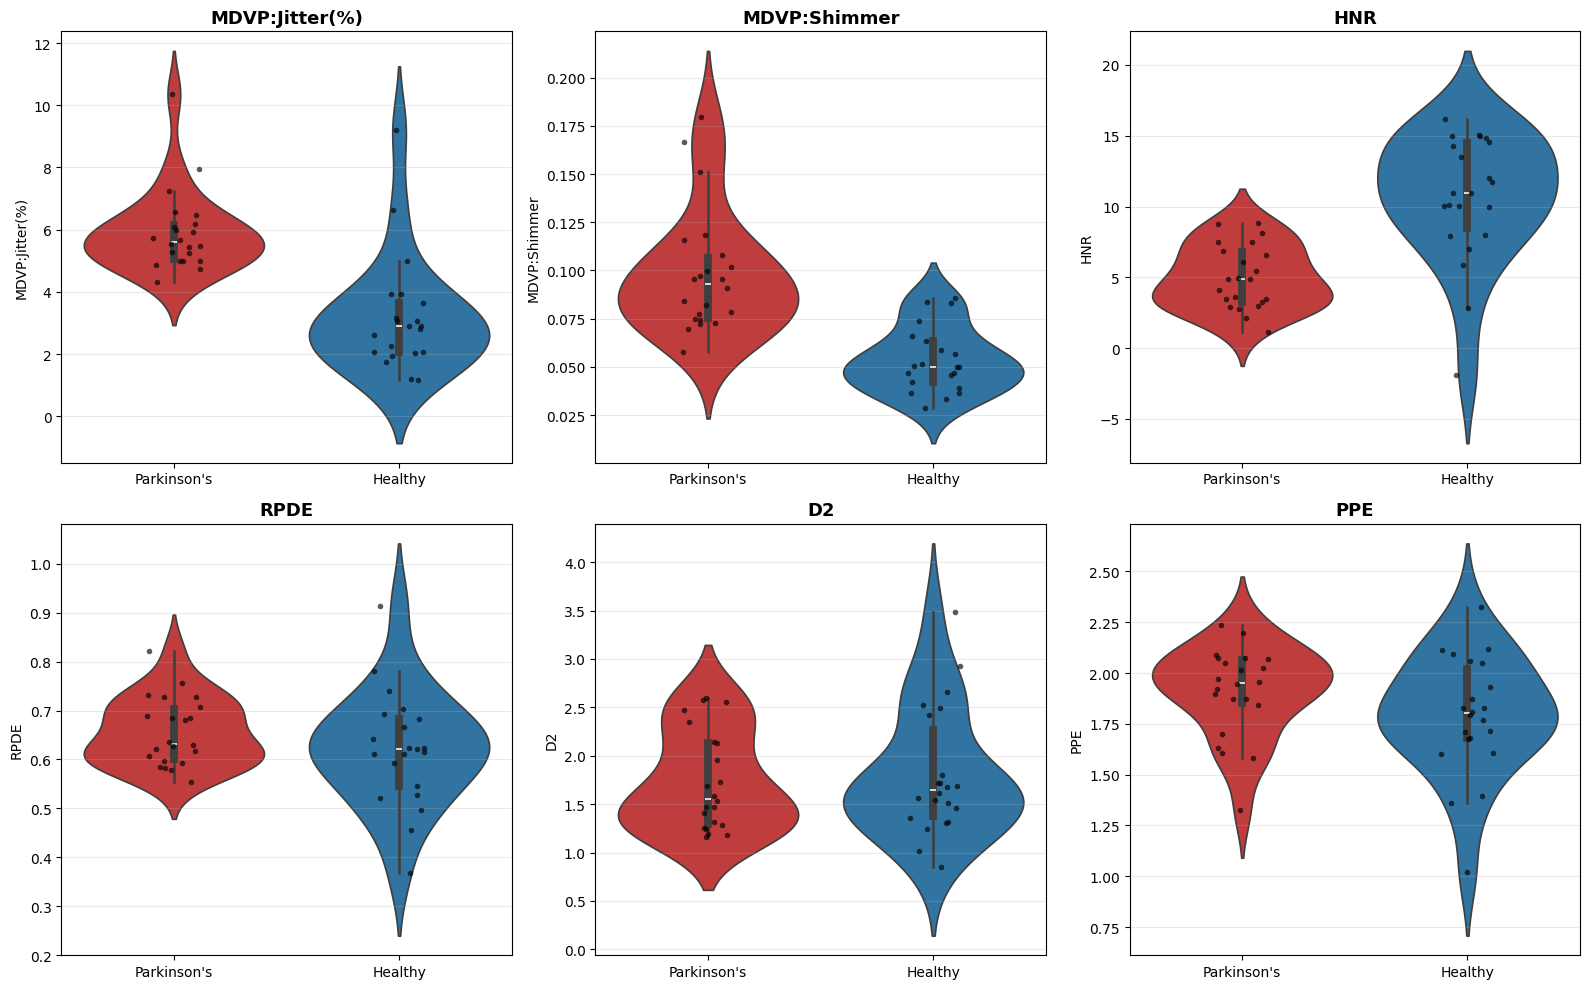

In [62]:
# ============================================================
# Violin plots with swapped Healthy/Parkinson's display labels
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Use one row per subject, with mean value of every feature
plot_df = subject_mean_df.copy()

# Swap the displayed class names
plot_df["Class"] = plot_df["status"].map({
    0: "Parkinson's",
    1: "Healthy"
})

# Features to visualize
features = [
    "MDVP:Jitter(%)",
    "MDVP:Shimmer",
    "HNR",
    "RPDE",
    "D2",
    "PPE"
]

# Color selection
palette = {
    "Healthy": "#1f77b4",        # Blue
    "Parkinson's": "#d62728"     # Red
}

# Create a 2 × 3 plot layout
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, features):

    # Distribution, median, and interquartile range
    sns.violinplot(
        data=plot_df,
        x="Class",
        y=feature,
        hue="Class",
        palette=palette,
        inner="box",
        legend=False,
        ax=ax
    )

    # Individual subject values
    sns.stripplot(
        data=plot_df,
        x="Class",
        y=feature,
        color="black",
        alpha=0.65,
        size=4,
        jitter=0.12,
        ax=ax
    )

    ax.set_title(feature, fontweight="bold", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel(feature)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

# Save high-resolution image for the report
plt.savefig(
    "healthy_vs_parkinsons_violin_plots_swapped_labels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
df.head(
    
)

,subject,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,Anna B,211.500233,398.994190,153.833290,14.113187,0.000688,0.078772,0.097230,0.236317,0.110255,2.182855,0.023227,0.039348,0.117922,0.069680,1.031038,-0.132746,0.977820,1.488822,0.276502,0.117322,1.010945,1.909324,1
1,Anna B,174.783371,202.984243,151.190526,11.954652,0.000685,0.066700,0.082743,0.200100,0.129743,2.174289,0.031249,0.051539,0.132004,0.093747,0.406525,3.909131,0.945193,1.238823,0.062140,0.033163,1.159814,2.720566,1
2,Anna B,193.885377,202.984243,165.829546,0.805916,0.000042,0.004898,0.005394,0.014695,0.022671,0.233896,0.010978,0.012376,0.017834,0.032934,0.034833,14.580033,0.279043,0.965498,0.017994,0.005576,2.495142,1.800221,1
3,Anna B,183.808059,188.300183,175.690284,0.596443,0.000032,0.003796,0.003892,0.011388,0.018467,0.161590,0.008478,0.010050,0.014423,0.025434,0.023276,16.330825,0.661133,1.166487,0.012167,0.003737,1.685730,2.079876,1
4,Anna B,196.292188,204.160119,143.531535,0.892388,0.000045,0.005384,0.005902,0.016152,0.023336,0.248924,0.011622,0.012270,0.017398,0.034865,0.021252,16.726038,0.384392,1.114864,0.035958,0.005476,1.448363,1.336412,1


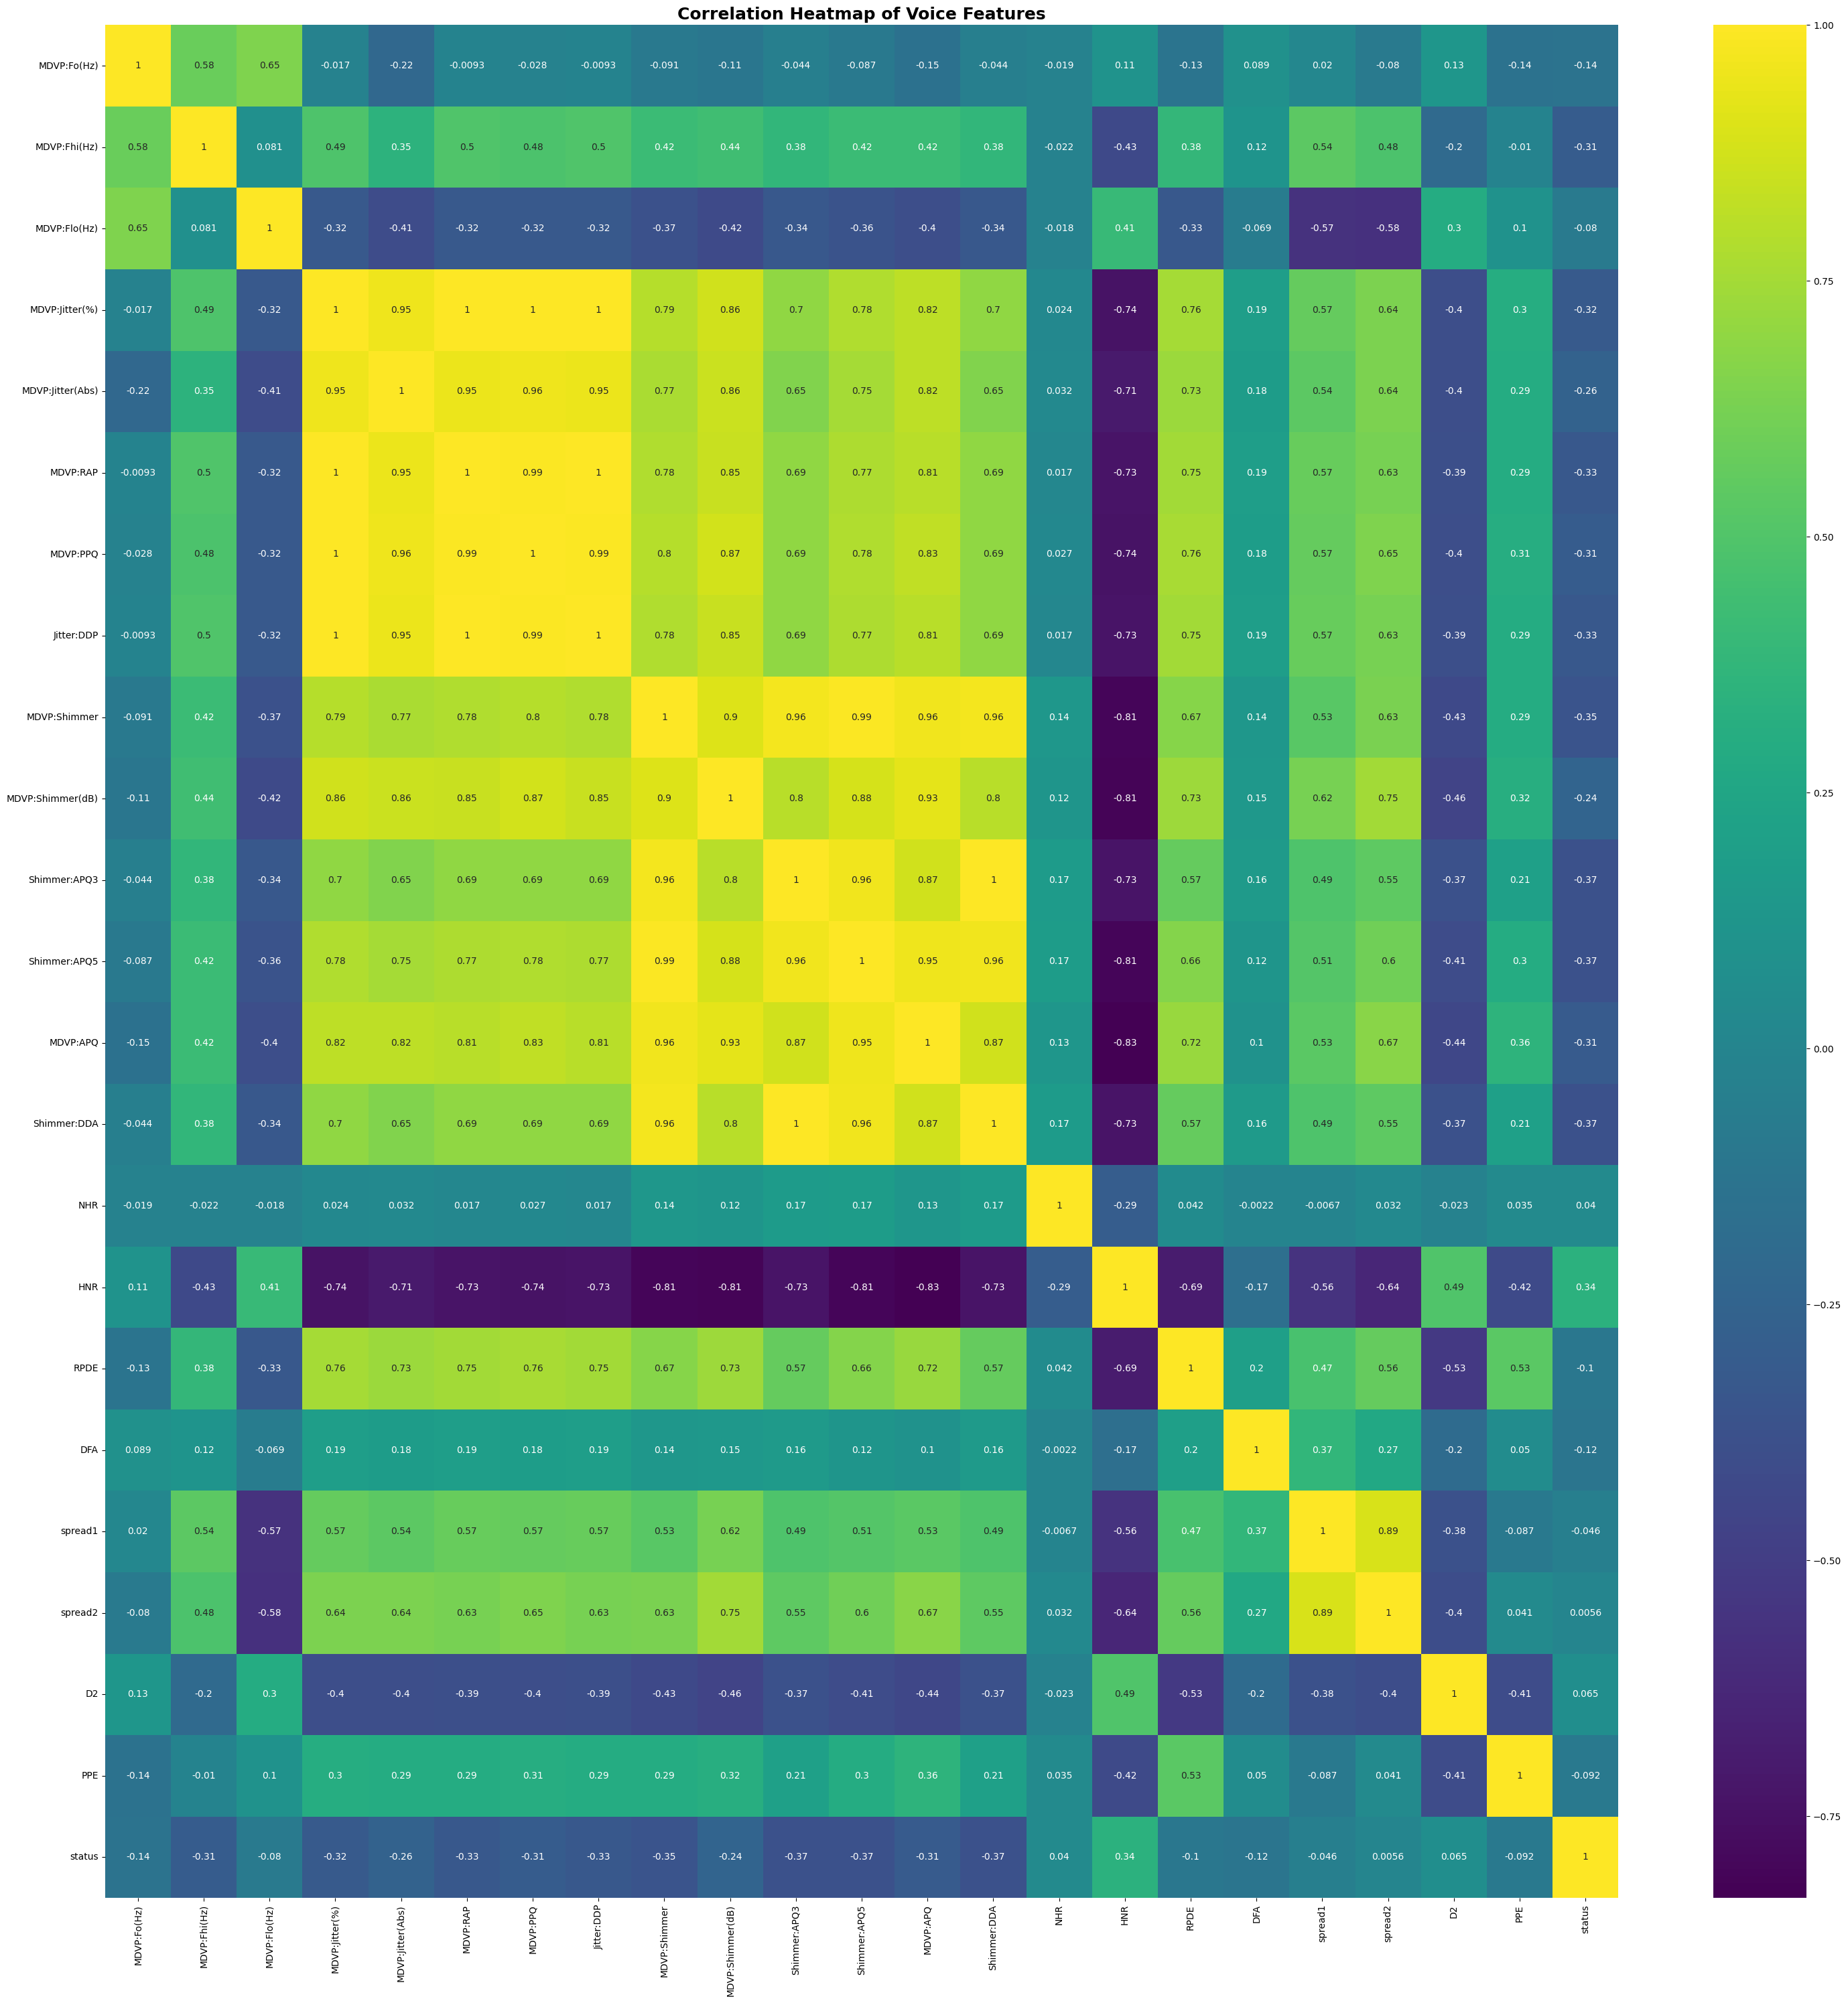

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30, 30))

corr = temp_df.iloc[:, 1:].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="viridis"
)

plt.title(
    "Correlation Heatmap of Voice Features",
    fontweight="bold",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    "feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()